In [1]:
# General-purpose libraries
import os
import glob
import pickle
import numpy as np
import pandas as pd
from random import sample

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib as mpl
import matplotlib
matplotlib.use('Agg')
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
from IPython.display import Image
%matplotlib inline
# Scikit-learn - Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split

# Scikit-learn - Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from sklearn.mixture import GaussianMixture

# Scikit-learn - Evaluation
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score, davies_bouldin_score,
    silhouette_samples, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.metrics.cluster import contingency_matrix

# Scikit-learn - Models
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import tree
from sklearn.preprocessing import OneHotEncoder

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
import tensorflow as tf
from tensorflow.keras import backend as K
from keras import backend as K

from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score
from keras.callbacks import ModelCheckpoint
from keras.layers import Dense, Input
from scipy.stats import pearsonr
from sklearn.model_selection import KFold
from sklearn.neural_network import MLPRegressor 
from tensorflow.keras import backend as K

from datetime import datetime
from itertools import product as iterproduct

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import random

In [4]:
df_original = pd.read_csv("dfR_datosclusterp2C.csv")

In [5]:
df_initial = df_original

In [6]:
df_initial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426 entries, 0 to 425
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Material                   426 non-null    object 
 1   AR_Moisturecontent         426 non-null    float64
 2   AR_Ashcontent              426 non-null    float64
 3   AR_Volatilematter          426 non-null    float64
 4   AR_Fixedcarbon             426 non-null    float64
 5   AR_Netcalorificvalue(LHV)  426 non-null    float64
 6   AR_Carbon                  426 non-null    float64
 7   AR_Hydrogen                426 non-null    float64
 8   AR_Nitrogen                426 non-null    float64
 9   AR_Sulphur                 426 non-null    float64
 10  AR_Oxygen                  426 non-null    float64
 11  cluster                    426 non-null    int64  
dtypes: float64(10), int64(1), object(1)
memory usage: 40.1+ KB


In [7]:
df_initial.describe()

,AR_Moisturecontent,AR_Ashcontent,AR_Volatilematter,AR_Fixedcarbon,AR_Netcalorificvalue(LHV),AR_Carbon,AR_Hydrogen,AR_Nitrogen,AR_Sulphur,AR_Oxygen,cluster
count,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.00000,426.000000,426.000000,426.000000
mean,15.834225,9.071643,58.837183,16.186455,14.572324,39.846526,4.620352,0.85007,0.221479,29.472207,0.814554
std,17.120690,12.502600,18.588593,11.902826,5.164174,12.658616,1.310713,0.99315,0.321585,10.672648,1.150294
min,0.100000,0.060000,4.820000,0.600000,0.190000,6.200000,0.750000,0.02000,0.010000,0.920000,0.000000
25%,6.310000,1.352500,46.072500,11.172500,12.022500,33.225000,3.972500,0.23000,0.040000,22.232500,0.000000
50%,9.790000,4.110000,65.775000,14.220000,15.320000,42.015000,5.030000,0.52000,0.080000,34.085000,0.000000
75%,15.000000,9.417500,72.700000,16.820000,16.797500,46.247500,5.467500,1.06000,0.247500,38.057500,2.000000
max,83.700000,64.110000,85.780000,87.700000,34.340000,87.250000,8.320000,5.48000,1.990000,43.410000,3.000000


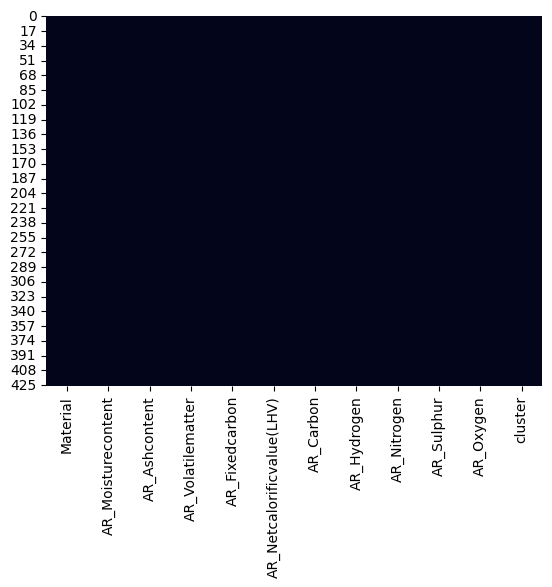

In [8]:
sns.heatmap(df_initial.isnull(), cbar=False)
plt.show()

In [9]:
df_initial1=df_initial

In [10]:
df_initial1

,Material,AR_Moisturecontent,AR_Ashcontent,AR_Volatilematter,AR_Fixedcarbon,AR_Netcalorificvalue(LHV),AR_Carbon,AR_Hydrogen,AR_Nitrogen,AR_Sulphur,AR_Oxygen,cluster
0,bark,12.30,3.50,70.36,13.84,15.73,44.16,5.11,0.10,0.06,34.75,0
1,wood,10.00,0.32,75.59,14.09,16.26,44.87,5.51,0.09,0.08,39.11,0
2,wood,8.12,0.40,76.84,14.64,16.85,46.98,5.26,0.13,0.03,39.06,0
3,wood,12.37,0.55,73.98,13.10,15.53,44.65,4.99,0.11,0.04,37.26,0
4,wood,10.00,0.78,76.03,13.19,16.28,45.13,5.49,0.03,0.03,38.52,0
...,...,...,...,...,...,...,...,...,...,...,...,...
421,Litchi,59.86,0.96,27.50,11.68,5.30,17.50,2.75,0.46,0.03,18.44,1
422,Longan,35.06,2.16,45.30,17.48,10.05,27.99,4.45,0.77,0.05,29.52,3
423,bituminous,3.00,9.30,33.20,54.49,28.14,71.91,4.65,1.23,0.35,9.56,2
424,wood,12.40,0.90,71.70,15.00,16.69,46.21,5.38,0.09,0.01,35.03,0


In [11]:
path_data = ("")
df_initial1= path_data + 'dfR_datosclusterp2C.csv'

In [ ]:
df_initial2= np.genfromtxt(df_initial1, delimiter=',', skip_header=1)
df_initial2 = df_initial2[:, 1:]

In [13]:
df_escalada=pd.DataFrame(data=df_initial2)

In [14]:
df_escalada.describe()

,0,1,2,3,4,5,6,7,8,9,10
count,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.00000,426.000000,426.000000,426.000000
mean,15.834225,9.071643,58.837183,16.186455,14.572324,39.846526,4.620352,0.85007,0.221479,29.472207,0.814554
std,17.120690,12.502600,18.588593,11.902826,5.164174,12.658616,1.310713,0.99315,0.321585,10.672648,1.150294
min,0.100000,0.060000,4.820000,0.600000,0.190000,6.200000,0.750000,0.02000,0.010000,0.920000,0.000000
25%,6.310000,1.352500,46.072500,11.172500,12.022500,33.225000,3.972500,0.23000,0.040000,22.232500,0.000000
50%,9.790000,4.110000,65.775000,14.220000,15.320000,42.015000,5.030000,0.52000,0.080000,34.085000,0.000000
75%,15.000000,9.417500,72.700000,16.820000,16.797500,46.247500,5.467500,1.06000,0.247500,38.057500,2.000000
max,83.700000,64.110000,85.780000,87.700000,34.340000,87.250000,8.320000,5.48000,1.990000,43.410000,3.000000


In [15]:
df6=pd.DataFrame((df_escalada.values), columns=['AR_Moisturecontent','AR_Ashcontent','AR_Volatilematter','AR_Fixedcarbon','AR_Netcalorificvalue(LHV)','AR_Carbon','AR_Hydrogen',	'AR_Nitrogen',	'AR_Sulphur',	'AR_Oxygen',	'cluster' ])

In [16]:
df6.describe()

,AR_Moisturecontent,AR_Ashcontent,AR_Volatilematter,AR_Fixedcarbon,AR_Netcalorificvalue(LHV),AR_Carbon,AR_Hydrogen,AR_Nitrogen,AR_Sulphur,AR_Oxygen,cluster
count,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.00000,426.000000,426.000000,426.000000
mean,15.834225,9.071643,58.837183,16.186455,14.572324,39.846526,4.620352,0.85007,0.221479,29.472207,0.814554
std,17.120690,12.502600,18.588593,11.902826,5.164174,12.658616,1.310713,0.99315,0.321585,10.672648,1.150294
min,0.100000,0.060000,4.820000,0.600000,0.190000,6.200000,0.750000,0.02000,0.010000,0.920000,0.000000
25%,6.310000,1.352500,46.072500,11.172500,12.022500,33.225000,3.972500,0.23000,0.040000,22.232500,0.000000
50%,9.790000,4.110000,65.775000,14.220000,15.320000,42.015000,5.030000,0.52000,0.080000,34.085000,0.000000
75%,15.000000,9.417500,72.700000,16.820000,16.797500,46.247500,5.467500,1.06000,0.247500,38.057500,2.000000
max,83.700000,64.110000,85.780000,87.700000,34.340000,87.250000,8.320000,5.48000,1.990000,43.410000,3.000000


In [17]:
df7 = df6.drop(columns=['cluster'])
df7.describe()

,AR_Moisturecontent,AR_Ashcontent,AR_Volatilematter,AR_Fixedcarbon,AR_Netcalorificvalue(LHV),AR_Carbon,AR_Hydrogen,AR_Nitrogen,AR_Sulphur,AR_Oxygen
count,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.000000,426.00000,426.000000,426.000000
mean,15.834225,9.071643,58.837183,16.186455,14.572324,39.846526,4.620352,0.85007,0.221479,29.472207
std,17.120690,12.502600,18.588593,11.902826,5.164174,12.658616,1.310713,0.99315,0.321585,10.672648
min,0.100000,0.060000,4.820000,0.600000,0.190000,6.200000,0.750000,0.02000,0.010000,0.920000
25%,6.310000,1.352500,46.072500,11.172500,12.022500,33.225000,3.972500,0.23000,0.040000,22.232500
50%,9.790000,4.110000,65.775000,14.220000,15.320000,42.015000,5.030000,0.52000,0.080000,34.085000
75%,15.000000,9.417500,72.700000,16.820000,16.797500,46.247500,5.467500,1.06000,0.247500,38.057500
max,83.700000,64.110000,85.780000,87.700000,34.340000,87.250000,8.320000,5.48000,1.990000,43.410000


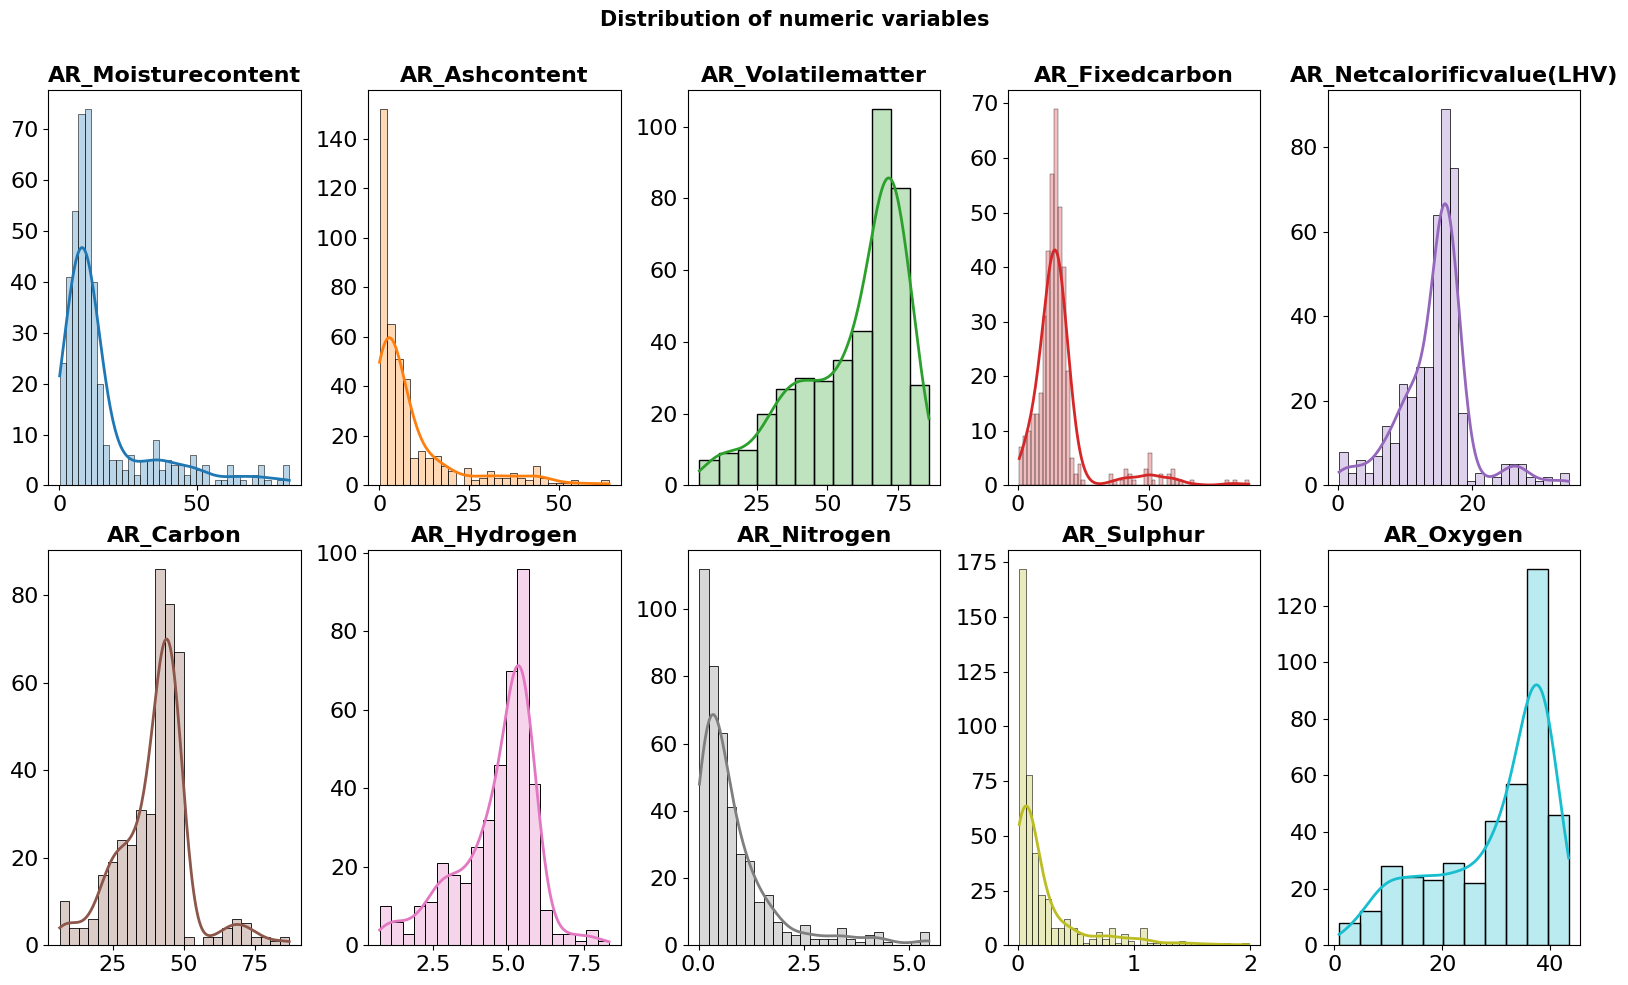

In [19]:
# Distribution plot for each numeric variable
# ==============================================================================
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(16, 10))
axes = axes.flat
numeric_columns = df6.select_dtypes(include=['float64', 'int']).columns
numeric_columns = numeric_columns.drop('cluster')
for i, column in enumerate(numeric_columns):
    sns.histplot(
        data    = df6,
        x       = column,
        stat    = "count",
        kde     = True,
        color   = (list(plt.rcParams['axes.prop_cycle'])*2)[i]["color"],
        line_kws= {'linewidth': 2},
        alpha   = 0.3,
        ax      = axes[i]
    )
    axes[i].tick_params(axis='both', which='major', labelsize=16)
    axes[i].set_title(column, fontsize = 16, fontweight = "bold")
    axes[i].tick_params(labelsize = 16)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    
fig.tight_layout()
plt.subplots_adjust(top = 0.9)
fig.suptitle('Distribution of numeric variables', fontsize = 15, fontweight = "bold");
fig.savefig('Distribution.png')
plt.show()

In [20]:
cmap = sns.diverging_palette(250, 15, s=75, l=40, center="light", as_cmap=True)

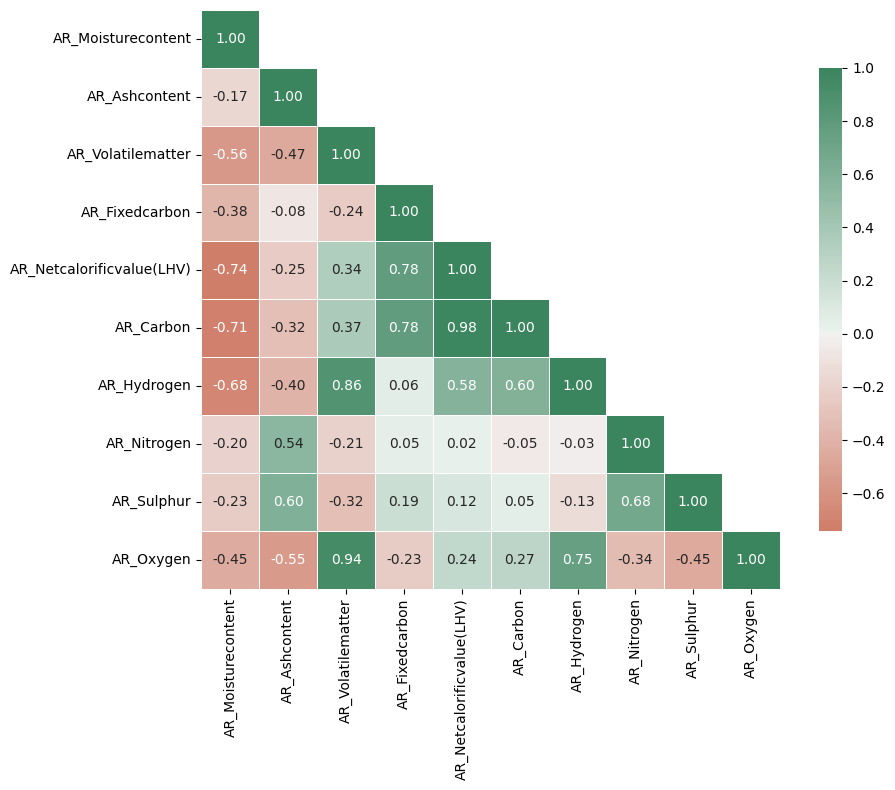

In [ ]:

matrix = df7.corr()
mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)
cmap = sns.diverging_palette(20, 145, as_cmap=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matrix, mask=mask, center=0, annot=True, fmt='.2f',
            square=True, cmap=cmap, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8}, ax=ax)
fig.tight_layout()
fig.savefig('correlation_matrix.png', format='png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

In [23]:
 y_dependiente= df6[['AR_Carbon','AR_Hydrogen','AR_Nitrogen','AR_Sulphur','AR_Oxygen']]

In [24]:
x_independiente = df6[['AR_Moisturecontent','AR_Ashcontent'	,'AR_Volatilematter'	,'AR_Fixedcarbon',	'AR_Netcalorificvalue(LHV)','cluster']]

In [25]:
y_dependiente

,AR_Carbon,AR_Hydrogen,AR_Nitrogen,AR_Sulphur,AR_Oxygen
0,44.16,5.11,0.10,0.06,34.75
1,44.87,5.51,0.09,0.08,39.11
2,46.98,5.26,0.13,0.03,39.06
3,44.65,4.99,0.11,0.04,37.26
4,45.13,5.49,0.03,0.03,38.52
...,...,...,...,...,...
421,17.50,2.75,0.46,0.03,18.44
422,27.99,4.45,0.77,0.05,29.52
423,71.91,4.65,1.23,0.35,9.56
424,46.21,5.38,0.09,0.01,35.03


In [26]:
x_independiente

,AR_Moisturecontent,AR_Ashcontent,AR_Volatilematter,AR_Fixedcarbon,AR_Netcalorificvalue(LHV),cluster
0,12.30,3.50,70.36,13.84,15.73,0.0
1,10.00,0.32,75.59,14.09,16.26,0.0
2,8.12,0.40,76.84,14.64,16.85,0.0
3,12.37,0.55,73.98,13.10,15.53,0.0
4,10.00,0.78,76.03,13.19,16.28,0.0
...,...,...,...,...,...,...
421,59.86,0.96,27.50,11.68,5.30,1.0
422,35.06,2.16,45.30,17.48,10.05,3.0
423,3.00,9.30,33.20,54.49,28.14,2.0
424,12.40,0.90,71.70,15.00,16.69,0.0


In [ ]:
# Hyperparameter training code


y_dependent = y_dependent.rename(columns={
    'AR_Carbon':   'C',
    'AR_Hydrogen': 'H',
    'AR_Nitrogen': 'N',
    'AR_Sulphur':  'S',
    'AR_Oxygen':   'O',
})

# ── Output names ────────────────────────────────────────────────
OUTPUT_NAMES  = ['C', 'H', 'N', 'S', 'O']

# Equal weight for all variables
SCORE_WEIGHTS = {'C': 0.20, 'H': 0.20, 'N': 0.20, 'S': 0.20, 'O': 0.20}

# Architectures with UNIQUE keys
ARCHITECTURES = {
    'prog_2_small_A':   [150, 96],
    
    'prog_5_medium_B':  [300, 150],
    
}

# Correct initializer according to activation (He 2015 / Glorot 2010)
INITIALIZER_MAP = {
    'relu':    'he_normal',
    
    'tanh':    'glorot_uniform',
    
}

EXPERIMENT_ROOT = "experiments"
os.makedirs(EXPERIMENT_ROOT, exist_ok=True)
# 0. UNIQUE FOLDER PER FOLD

def make_run_folder(arch_name, activation, dropout, lr, batch_size, fold_idx):
    ts   = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    name = (f"{arch_name}_act{activation}_"
            f"dr{str(dropout).replace('.','')}_"
            f"lr{str(lr).replace('.','')}_"
            f"bs{batch_size}_fold{fold_idx:02d}_{ts}")
    path = os.path.join(EXPERIMENT_ROOT, name)
    os.makedirs(path, exist_ok=True)
    return path
# 1. DATA PREPROCESSING
def preprocess_data_fold(train_idx, test_idx):
    X_train = x_independent.iloc[train_idx]
    X_test  = x_independent.iloc[test_idx]
    y_train = y_dependent.iloc[train_idx]
    y_test  = y_dependent.iloc[test_idx]

    numerical_X_cols = [col for col in X_train.columns if col != 'cluster']
    X_train_numerical = X_train[numerical_X_cols]
    X_test_numerical  = X_test[numerical_X_cols]

    encoder_X_categorical = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    X_train_cat = encoder_X_categorical.fit_transform(X_train[['cluster']])
    X_test_cat  = encoder_X_categorical.transform(X_test[['cluster']])

    ohe_col_names = encoder_X_categorical.get_feature_names_out(['cluster']).tolist()
    X_train_cat_df = pd.DataFrame(X_train_cat, index=X_train.index, columns=ohe_col_names)
    X_test_cat_df  = pd.DataFrame(X_test_cat,  index=X_test.index,  columns=ohe_col_names)
    # drop the last one-hot category (kept as the reference category)
    X_train_cat_df = X_train_cat_df.iloc[:, :-1]
    X_test_cat_df  = X_test_cat_df.iloc[:, :-1]

    scaler_X = StandardScaler()
    X_train_num_scaled = scaler_X.fit_transform(X_train_numerical)
    X_test_num_scaled  = scaler_X.transform(X_test_numerical)
    X_train_num_df = pd.DataFrame(X_train_num_scaled,
                                   index=X_train.index, columns=numerical_X_cols)
    X_test_num_df  = pd.DataFrame(X_test_num_scaled,
                                   index=X_test.index,  columns=numerical_X_cols)

    X_train_scaled = pd.concat([X_train_num_df, X_train_cat_df], axis=1)
    X_test_scaled  = pd.concat([X_test_num_df,  X_test_cat_df],  axis=1)

    y_cols = y_train.columns.tolist()
    scalers_y = {}
    y_train_scaled_list = []
    y_test_scaled_list  = []
    for col in y_cols:
        sc = StandardScaler()
        y_train_scaled_list.append(sc.fit_transform(y_train[[col]]))
        y_test_scaled_list.append(sc.transform(y_test[[col]]))
        scalers_y[col] = sc

    y_train_scaled = pd.DataFrame(
        np.hstack(y_train_scaled_list),
        index=y_train.index, columns=y_cols)
    y_test_scaled = pd.DataFrame(
        np.hstack(y_test_scaled_list),
        index=y_test.index, columns=y_cols)

    train_clusters = X_train['cluster'].values

    return (X_train_scaled, X_test_scaled,
            y_train_scaled, y_test_scaled,
            scaler_X, scalers_y,
            encoder_X_categorical,
            train_clusters)
# 2. KERAS METRIC

@tf.function(reduce_retracing=True)
def r2_mean_per_output(y_true, y_pred):
    """Average R² calculated per column (output)."""
    n_outputs = tf.shape(y_true)[1]
    r2_sum = 0.0
    for i in tf.range(n_outputs):
        col_true = y_true[:, i]
        col_pred = y_pred[:, i]
        ss_res = tf.reduce_sum(tf.square(col_true - col_pred))
        ss_tot = tf.reduce_sum(tf.square(col_true - tf.reduce_mean(col_true)))
        r2_sum += 1.0 - ss_res / (ss_tot + 1e-8)
    return r2_sum / tf.cast(n_outputs, tf.float32)
# 3. MODEL
def build_model(arch_layers, activation, dropout_rate, lr, l2_reg,
                input_dim=9, output_dim=5):
    initializer = INITIALIZER_MAP.get(activation, 'glorot_uniform')
    clf = Sequential()
    clf.add(Input(shape=(input_dim,)))
    for units in arch_layers:
        clf.add(Dense(units, kernel_initializer=initializer,
                      kernel_regularizer=l2(l2_reg),
                      activation=activation))
        if dropout_rate > 0.0:
            clf.add(Dropout(dropout_rate))
    clf.add(Dense(output_dim, activation='linear'))
    clf.compile(optimizer=Adam(learning_rate=lr),
                loss='mse',
                metrics=[r2_mean_per_output])
    return clf
# WeightCapture callback
class WeightCapture(Callback):
    """Captures the weights of the epoch with the best val_loss.
    Always works, even if EarlyStopping never triggers."""
    def __init__(self):
        super().__init__()
        self.best_loss    = np.inf
        self.best_weights = None
        self.best_epoch   = 0

    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get('val_loss')
        if val_loss is not None and val_loss < self.best_loss:
            self.best_loss    = val_loss
            self.best_weights = [w.copy() for w in self.model.get_weights()]
            self.best_epoch   = epoch
# 4. HELPER FUNCTIONS
def inverse_transform_y(scalers_y, arr, y_cols):
    arr = np.array(arr, dtype=np.float64)
    result = np.zeros_like(arr)
    for i, col in enumerate(y_cols):
        result[:, i] = scalers_y[col].inverse_transform(arr[:, [i]]).ravel()
    return result


def global_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / (ss_tot + 1e-8)


def metrics_per_output(y_true, y_pred, names):
    out = {}
    for i, name in enumerate(names):
        out[f'MSE_{name}'] = mean_squared_error(y_true[:, i], y_pred[:, i])
        out[f'R2_{name}']  = r2_score(y_true[:, i], y_pred[:, i])
    return out


def compute_score(m_test_out, score_weights, names):
    return sum(score_weights[n] * m_test_out[f'R2_{n}'] for n in names)


def fast_predict(model, X_np):
    return model(tf.constant(X_np, dtype=tf.float32), training=False).numpy()
# 5. PER-RUN PLOTS
def plot_learning_curves(history, folder, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ep = range(1, len(history.history['loss']) + 1)
    axes[0].plot(ep, history.history['loss'],     label='Train')
    axes[0].plot(ep, history.history['val_loss'], label='Val')
    axes[0].set_title('Loss (MSE)'); axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(ep, history.history['r2_mean_per_output'],     label='Train (batch avg.)')
    axes[1].plot(ep, history.history['val_r2_mean_per_output'], label='Val')
    axes[1].set_title('R² Mean per Output'); axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    fig.suptitle(title, fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(folder, 'learning_curves.png'), dpi=120)
    plt.close(fig)


def plot_pred_vs_real_per_output(y_true, y_pred, folder, title, names):
    n = len(names)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1: axes = [axes]
    for i, (ax, name) in enumerate(zip(axes, names)):
        r2  = r2_score(y_true[:, i], y_pred[:, i])
        mse = mean_squared_error(y_true[:, i], y_pred[:, i])
        color = 'tomato' if name in ('H', 'N', 'S') else 'steelblue'
        ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.5, s=18, color=color)
        mn = min(y_true[:, i].min(), y_pred[:, i].min())
        mx = max(y_true[:, i].max(), y_pred[:, i].max())
        ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
        ax.set_title(f'{name}\nR²={r2:.4f}  MSE={mse:.4f}', fontsize=9)
        ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
        ax.grid(True, alpha=0.3)
    fig.suptitle(f'Predicted vs Actual (test) — {title}', fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(folder, 'pred_vs_real_per_output.png'), dpi=120)
    plt.close(fig)


def plot_residuals_per_output(y_true, y_pred, folder, title, names):
    n = len(names)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1: axes = [axes]
    for i, (ax, name) in enumerate(zip(axes, names)):
        res = y_true[:, i] - y_pred[:, i]
        ax.scatter(y_pred[:, i], res, alpha=0.5, s=18, color='coral')
        ax.axhline(0, color='k', linestyle='--', lw=1.5)
        ax.set_title(f'Residuals — {name}', fontsize=9)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Residual')
        ax.grid(True, alpha=0.3)
    fig.suptitle(title, fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(folder, 'residuals_per_output.png'), dpi=120)
    plt.close(fig)


def plot_r2_bar_per_output(metrics_train, metrics_test, folder, title, names):
    r2_train = [metrics_train[f'R2_{n}'] for n in names]
    r2_test  = [metrics_test[f'R2_{n}']  for n in names]
    x = np.arange(len(names)); w = 0.35
    fig, ax = plt.subplots(figsize=(9, 4))
    bars_tr = ax.bar(x - w/2, r2_train, w, label='Train', color='steelblue')
    bars_te = ax.bar(x + w/2, r2_test,  w, label='Test',  color='coral')
    for idx, name in enumerate(names):
        if name in ('H', 'N', 'S'):
            bars_tr[idx].set_edgecolor('black'); bars_tr[idx].set_linewidth(2)
            bars_te[idx].set_edgecolor('black'); bars_te[idx].set_linewidth(2)
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
    ax.set_ylabel('R²'); ax.set_title(f'R² per Output — {title}', fontsize=9)
    ax.legend(); ax.set_ylim(0, 1.05); ax.grid(True, axis='y', alpha=0.3)
    ax.axhline(0.9, color='green', linestyle=':', lw=1.2, label='R²=0.9')
    plt.tight_layout()
    plt.savefig(os.path.join(folder, 'r2_per_output_bar.png'), dpi=120)
    plt.close(fig)


def plot_mse_bar_per_output(metrics_train, metrics_test, folder, title, names):
    mse_train = [metrics_train[f'MSE_{n}'] for n in names]
    mse_test  = [metrics_test[f'MSE_{n}']  for n in names]
    x = np.arange(len(names)); w = 0.35
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(x - w/2, mse_train, w, label='Train', color='steelblue')
    ax.bar(x + w/2, mse_test,  w, label='Test',  color='coral')
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
    ax.set_ylabel('MSE'); ax.set_title(f'MSE per Output — {title}', fontsize=9)
    ax.legend(); ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(folder, 'mse_per_output_bar.png'), dpi=120)
    plt.close(fig)


def plot_error_dist_per_output(y_true, y_pred, folder, title, names):
    n = len(names)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1: axes = [axes]
    for i, (ax, name) in enumerate(zip(axes, names)):
        err = y_true[:, i] - y_pred[:, i]
        ax.hist(err, bins=25, color='mediumseagreen', edgecolor='black', alpha=0.8)
        ax.axvline(0, color='r', linestyle='--', lw=1.5)
        ax.set_title(f'{name}\nμ={err.mean():.3f}  σ={err.std():.3f}', fontsize=9)
        ax.set_xlabel('Error'); ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3)
    fig.suptitle(f'Error Distribution — {title}', fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(folder, 'error_dist_per_output.png'), dpi=120)
    plt.close(fig)
# 6. GLOBAL PLOTS
def plot_global_summary(df, save_dir, names):

    fig, ax = plt.subplots(figsize=(11, 5))
    df.boxplot(column='score', by='architecture', ax=ax)
    ax.set_title('Score by Architecture'); ax.set_xlabel('Architecture')
    plt.suptitle(''); plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'boxplot_score_architecture.png'), dpi=120)
    plt.close(fig)

    if df['dropout'].nunique() > 1:
        pivot = df.groupby(['architecture', 'dropout'])['score'].mean().unstack()
        fig, ax = plt.subplots(figsize=(9, 5))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax)
        ax.set_title('Average Score — Architecture × Dropout')
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'heatmap_arch_dropout.png'), dpi=120)
        plt.close(fig)

    if df['l2_reg'].nunique() > 1:
        pivot_l2 = df.groupby(['architecture', 'l2_reg'])['score'].mean().unstack()
        fig, ax = plt.subplots(figsize=(9, 5))
        sns.heatmap(pivot_l2, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax)
        ax.set_title('Average Score — Architecture × L2 Reg')
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'heatmap_arch_l2reg.png'), dpi=120)
        plt.close(fig)

    if df['activation'].nunique() > 1:
        pivot_act = df.groupby(['architecture', 'activation'])['score'].mean().unstack()
        fig, ax = plt.subplots(figsize=(9, 5))
        sns.heatmap(pivot_act, annot=True, fmt='.3f', cmap='viridis', ax=ax)
        ax.set_title('Average Score — Architecture × Activation')
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'heatmap_arch_activation.png'), dpi=120)
        plt.close(fig)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(df['train_R2_global'], df['test_R2_global'], alpha=0.5, s=30)
    lim = [df[['train_R2_global','test_R2_global']].min().min(),
           df[['train_R2_global','test_R2_global']].max().max()]
    ax.plot(lim, lim, 'r--', lw=1.5, label='No overfitting')
    ax.set_xlabel('R² Train'); ax.set_ylabel('R² Test')
    ax.set_title('Overfitting Detection'); ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'overfitting_scatter.png'), dpi=120)
    plt.close(fig)

    top10 = df.nlargest(10, 'score')
    r2_cols = [f'test_R2_{n}' for n in names]
    top10_r2 = top10[r2_cols].copy()
    top10_r2.columns = names
    top10_r2.index = range(1, len(top10_r2) + 1)
    fig, ax = plt.subplots(figsize=(10, 5))
    top10_r2.T.plot(kind='bar', ax=ax, colormap='tab10')
    ax.axhline(0.9, color='black', linestyle=':', lw=1.5, label='R²=0.9 target')
    ax.set_xlabel('Output'); ax.set_ylabel('R²')
    ax.set_title('R² per Output — Top 10')
    ax.legend(title='Config rank', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
    ax.set_ylim(0, 1.05); ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'top10_r2_per_output.png'), dpi=120)
    plt.close(fig)

    top10_g = df.nlargest(10, 'score').copy()
    top10_g['config'] = (top10_g['architecture'] + '_' +
                         top10_g['activation'] + '_dr' +
                         top10_g['dropout'].astype(str) + '_lr' +
                         top10_g['lr'].astype(str))
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(range(len(top10_g)), top10_g['score'], color='steelblue')
    ax.set_yticks(range(len(top10_g)))
    ax.set_yticklabels(top10_g['config'], fontsize=8)
    ax.set_xlabel('Score'); ax.set_title('Top 10 by Score')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'top10_score.png'), dpi=120)
    plt.close(fig)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, var in zip(axes, ['H', 'N', 'S']):
        vals = df[f'test_R2_{var}'].reset_index(drop=True)
        ax.plot(vals, marker='o', markersize=3, linewidth=0.8, color='tomato')
        ax.axhline(0.9, color='green', linestyle='--', lw=1.5, label='Target 0.9')
        ax.axhline(vals.max(), color='blue', linestyle=':', lw=1.2,
                   label=f'Max={vals.max():.3f}')
        ax.set_title(f'R² {var} — all folds')
        ax.set_xlabel('Fold'); ax.set_ylabel('R²')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'r2_HNS_evolution.png'), dpi=120)
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(df['best_epoch'], bins=20, color='coral', edgecolor='black')
    ax.set_xlabel('Optimal epoch'); ax.set_title('Distribution of Epoch with Best Val Loss')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'best_epoch_dist.png'), dpi=120)
    plt.close(fig)

    group_cols = ['architecture', 'arch_layers', 'activation',
                  'dropout', 'l2_reg', 'lr', 'batch_size']
    cv_summary = df.groupby(group_cols)['score'].agg(['mean', 'std']).reset_index()
    cv_summary = cv_summary.sort_values('mean', ascending=False).head(10)
    cv_summary['config'] = (cv_summary['architecture'] + '_' +
                             cv_summary['activation'] + '_dr' +
                             cv_summary['dropout'].astype(str) + '_lr' +
                             cv_summary['lr'].astype(str))
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(range(len(cv_summary)), cv_summary['mean'], xerr=cv_summary['std'],
            color='steelblue', capsize=4)
    ax.set_yticks(range(len(cv_summary)))
    ax.set_yticklabels(cv_summary['config'], fontsize=8)
    ax.set_xlabel('Average score (±std) K-Fold')
    ax.set_title('Top 10 configs — K-Fold Average')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'top10_cv_mean_score.png'), dpi=120)
    plt.close(fig)

    print(f"\n Global plots saved in: {save_dir}")


# 7. SEARCH PARAMETERS
PARAM_GRID = {
    'architecture': list(ARCHITECTURES.keys()),
    'activation':   ['relu', 'tanh'],
    'batch_size':   [8, 16],
    'dropout_rate': [0.10, 0.005],
    'lr':           [3e-4,1e-3],
    'l2_reg':       [1e-4,1e-3],
}

# ── Random K-Fold
N_SPLITS       = 3
EPOCHS         = 1000
PATIENCE       = 70
VAL_FROM_TRAIN = 0.15

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
fold_splits = list(kf.split(x_independent))

random.seed(42)
all_keys   = list(PARAM_GRID.keys())
all_combos = list(iterproduct(*PARAM_GRID.values()))
random.shuffle(all_combos)
sampled_params = [dict(zip(all_keys, combo)) for combo in all_combos]

N_SEARCH   = len(sampled_params)
TOTAL_RUNS = N_SEARCH * N_SPLITS
print(f"\ Exhaustive grid: {N_SEARCH} configs × {N_SPLITS} folds = {TOTAL_RUNS} runs")
print(f"   Architectures: {len(ARCHITECTURES)}")
print(f"   Activations:  {PARAM_GRID['activation']}")
print(f"   lr: {PARAM_GRID['lr']}  l2: {PARAM_GRID['l2_reg']}  (already validated)")
print(f"   Internal val: {VAL_FROM_TRAIN*100:.0f}% of train (random)")
print(f"   Initializer: He/Glorot depending on activation")
print(f"   WeightCapture: always saves the best weights")
print(f"Example config #1: {sampled_params[0]}")

# 8. MAIN LOOP
csv_path        = os.path.join(EXPERIMENT_ROOT, 'results_kfold_clusterKp1.csv')
checkpoint_path = os.path.join(EXPERIMENT_ROOT, 'progress_kfold_clusterKp1.txt')

REQUIRED_COLS = {'architecture', 'arch_layers', 'dropout', 'l2_reg',
                 'lr', 'batch_size', 'activation', 'fold', 'score'}

if os.path.exists(csv_path):
    _prev = pd.read_csv(csv_path)
    if REQUIRED_COLS.issubset(_prev.columns):
        results   = _prev.to_dict('records')
        completed = set(zip(_prev['architecture'], _prev['arch_layers'],
                            _prev['dropout'], _prev['l2_reg'],
                            _prev['lr'], _prev['batch_size'],
                            _prev['activation'], _prev['fold']))
        print(f"\n Resuming — {len(results)} folds already completed")
    else:
        missing = REQUIRED_COLS - set(_prev.columns)
        print(f"\n  Existing CSV is incompatible (missing: {missing})")
        os.rename(csv_path, csv_path.replace('.csv', '_OLD.csv'))
        results   = []
        completed = set()
else:
    results   = []
    completed = set()
    print(f"\n Starting from scratch")

for p_idx, params in enumerate(sampled_params):
    arch_name    = params['architecture']
    arch_layers  = ARCHITECTURES[arch_name]
    activation   = params['activation']
    batch_size   = params['batch_size']
    dropout_rate = params['dropout_rate']
    lr           = params['lr']
    l2_reg       = params['l2_reg']

    title = (f"{arch_name} {arch_layers} {activation} "
             f"dr{dropout_rate} lr{lr} bs{batch_size} l2{l2_reg}")
    pct   = 100 * p_idx * N_SPLITS / TOTAL_RUNS
    print(f"\n{'='*65}")
    print(f"Config {p_idx+1}/{N_SEARCH}  [{pct:.1f}%]  {title}")
    print(f"{'='*65}")

    for fold_idx, (train_idx, test_idx) in enumerate(fold_splits):
        key = (arch_name, str(arch_layers), dropout_rate,
               l2_reg, lr, batch_size, activation, fold_idx + 1)
        if key in completed:
            print(f"  Fold {fold_idx+1}/{N_SPLITS} — already completed, skipping")
            continue

        print(f"  Fold {fold_idx+1}/{N_SPLITS} ...", end=' ', flush=True)

        run_folder = make_run_folder(arch_name, activation,
                                     dropout_rate, lr, batch_size, fold_idx+1)

        x_train, x_test, y_train, y_test, scaler_X, scalers_y, \
        encoder_X_categorical, train_clusters = preprocess_data_fold(train_idx, test_idx)

        x_train_np = x_train.values.astype(np.float32)
        y_train_np = y_train.values.astype(np.float32)
        x_test_np  = x_test.values.astype(np.float32)
        y_test_np  = y_test.values.astype(np.float32)

        # Split train → train_inner + val (random)
        train_idx_inner, val_idx_inner = train_test_split(
            np.arange(len(x_train_np)),
            test_size=VAL_FROM_TRAIN,
            random_state=42 + fold_idx)

        x_train_inner_np = x_train_np[train_idx_inner]
        y_train_inner_np = y_train_np[train_idx_inner]
        x_val_np         = x_train_np[val_idx_inner]
        y_val_np         = y_train_np[val_idx_inner]

        clf = build_model(arch_layers, activation, dropout_rate, lr, l2_reg,
                          input_dim=x_train_np.shape[1],
                          output_dim=y_train_np.shape[1])

        wc = WeightCapture()
        cbs = [
            wc,
            EarlyStopping(monitor='val_loss', patience=PATIENCE,
                          restore_best_weights=False, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=PATIENCE//2, min_lr=1e-7, verbose=0),
        ]

        history = clf.fit(x_train_inner_np, y_train_inner_np,
                          batch_size=batch_size, epochs=EPOCHS,
                          validation_data=(x_val_np, y_val_np),
                          verbose=0, callbacks=cbs)

        # Always restore from WeightCapture
        if wc.best_weights is not None:
            clf.set_weights(wc.best_weights)
        best_ep    = wc.best_epoch
        epochs_ran = len(history.history['loss'])

        if epochs_ran == EPOCHS:
            print(f"(max epochs, best={best_ep+1}) ", end='')

        yp_train = inverse_transform_y(scalers_y, fast_predict(clf, x_train_inner_np), OUTPUT_NAMES)
        yt_train = inverse_transform_y(scalers_y, y_train_inner_np,                    OUTPUT_NAMES)
        yp_val   = inverse_transform_y(scalers_y, fast_predict(clf, x_val_np),         OUTPUT_NAMES)
        yt_val   = inverse_transform_y(scalers_y, y_val_np,                            OUTPUT_NAMES)
        yp_test  = inverse_transform_y(scalers_y, fast_predict(clf, x_test_np),        OUTPUT_NAMES)
        yt_test  = inverse_transform_y(scalers_y, y_test_np,                           OUTPUT_NAMES)

        m_train_out = metrics_per_output(yt_train, yp_train, OUTPUT_NAMES)
        m_val_out   = metrics_per_output(yt_val,   yp_val,   OUTPUT_NAMES)
        m_test_out  = metrics_per_output(yt_test,  yp_test,  OUTPUT_NAMES)

        r2_train_g  = global_r2(yt_train, yp_train)
        r2_val_g    = global_r2(yt_val,   yp_val)
        r2_test_g   = global_r2(yt_test,  yp_test)
        mse_train_g = mean_squared_error(yt_train, yp_train, multioutput='uniform_average')
        mse_test_g  = mean_squared_error(yt_test,  yp_test,  multioutput='uniform_average')

        score = compute_score(m_test_out, SCORE_WEIGHTS, OUTPUT_NAMES)

        print(f"R²_global train={r2_train_g:.4f}  val={r2_val_g:.4f}  test={r2_test_g:.4f}  "
              f"score={score:.4f}  best_ep={best_ep+1}/{epochs_ran}")
        for n in OUTPUT_NAMES:
            mark = ' ◄' if n in ('H', 'N', 'S') else ''
            print(f"    {n}  train R²={m_train_out[f'R2_{n}']:.4f}"
                  f"  val R²={m_val_out[f'R2_{n}']:.4f}"
                  f"  test R²={m_test_out[f'R2_{n}']:.4f}{mark}")

        plot_learning_curves(history, run_folder, title)
        plot_pred_vs_real_per_output(yt_test, yp_test, run_folder, title, OUTPUT_NAMES)
        plot_residuals_per_output(yt_test, yp_test, run_folder, title, OUTPUT_NAMES)
        plot_r2_bar_per_output(m_train_out, m_test_out, run_folder, title, OUTPUT_NAMES)
        plot_mse_bar_per_output(m_train_out, m_test_out, run_folder, title, OUTPUT_NAMES)
        plot_error_dist_per_output(yt_test, yp_test, run_folder, title, OUTPUT_NAMES)

        with open(os.path.join(run_folder, 'params.txt'), 'w') as f:
            f.write(f"architecture={arch_name}\n"
                    f"arch_layers={arch_layers}\n"
                    f"activation={activation}\n"
                    f"kernel_initializer={INITIALIZER_MAP.get(activation, 'glorot_uniform')}\n"
                    f"dropout={dropout_rate}\nlr={lr}\nbatch_size={batch_size}\n"
                    f"l2_reg={l2_reg}\nfold={fold_idx+1}\n"
                    f"best_epoch={best_ep+1}\nepochs_ran={epochs_ran}\n"
                    f"val_from_train={VAL_FROM_TRAIN}\n"
                    f"uniform_kfold=True\n"
                    f"weight_capture=True\n"
                    f"train_R2_global={r2_train_g:.6f}\n"
                    f"val_R2_global={r2_val_g:.6f}\n"
                    f"test_R2_global={r2_test_g:.6f}\n"
                    f"score={score:.6f}\n")
            for n in OUTPUT_NAMES:
                f.write(f"train_R2_{n}={m_train_out[f'R2_{n}']:.6f}\n")
                f.write(f"val_R2_{n}={m_val_out[f'R2_{n}']:.6f}\n")
                f.write(f"test_R2_{n}={m_test_out[f'R2_{n}']:.6f}\n")

        row = {
            'architecture': arch_name, 'arch_layers': str(arch_layers),
            'activation': activation,
            'kernel_initializer': INITIALIZER_MAP.get(activation, 'glorot_uniform'),
            'dropout': dropout_rate, 'lr': lr, 'batch_size': batch_size,
            'l2_reg': l2_reg, 'fold': fold_idx + 1,
            'best_epoch': best_ep + 1, 'epochs_ran': epochs_ran,
            'train_MSE_global': mse_train_g, 'train_R2_global': r2_train_g,
            'val_R2_global': r2_val_g,
            'test_MSE_global': mse_test_g,  'test_R2_global': r2_test_g,
            'score': score, 'run_folder': run_folder,
        }
        row.update({f'train_{k}': v for k, v in m_train_out.items()})
        row.update({f'val_{k}':   v for k, v in m_val_out.items()})
        row.update({f'test_{k}':  v for k, v in m_test_out.items()})
        results.append(row)

        pd.DataFrame(results).to_csv(csv_path, index=False)
        with open(checkpoint_path, 'w') as f:
            f.write(f"config {p_idx+1}/{N_SEARCH}  fold {fold_idx+1}/{N_SPLITS}  "
                    f"{100*len(results)/TOTAL_RUNS:.1f}% completed\n")

# 9. GLOBAL RESULTS
results_dfk11 = pd.DataFrame(results)
results_dfk11.to_csv(csv_path, index=False)
print(f"\nCSV saved at: {csv_path}  ({len(results_dfk11)} folds)")

plot_global_summary(results_dfk11, EXPERIMENT_ROOT, OUTPUT_NAMES)

print("\n Top 10 folds (individual score):")
cols_show = (['architecture', 'arch_layers', 'activation', 'dropout', 'l2_reg',
              'lr', 'batch_size', 'fold', 'best_epoch', 'score', 'test_R2_global'] +
             [f'test_R2_{n}' for n in OUTPUT_NAMES])
print(results_dfk11.nlargest(10, 'score')[cols_show].to_string(index=False))

print("\n Top 10 configurations (K-Fold average):")
group_cols = ['architecture', 'arch_layers', 'activation',
              'dropout', 'l2_reg', 'lr', 'batch_size']
cv_summary = (results_dfk11.groupby(group_cols)['score']
              .agg(['mean', 'std', 'min', 'max'])
              .reset_index())
cv_summary = cv_summary.sort_values('mean', ascending=False)
print(cv_summary.head(10).to_string(index=False))

print("\n Average score by architecture:")
arch_summary = (results_dfk11.groupby('architecture')['score']
                .agg(['mean', 'std', 'max', 'count'])
                .round(4)
                .sort_values('mean', ascending=False))
print(arch_summary.to_string())

print("\n Average score by activation:")
act_summary = (results_dfk11.groupby('activation')['score']
               .agg(['mean', 'std', 'max', 'count'])
               .round(4)
               .sort_values('mean', ascending=False))
print(act_summary.to_string())

if 'epochs_ran' in results_dfk11.columns:
    max_ep_runs = results_dfk11[results_dfk11['epochs_ran'] == EPOCHS]
    if len(max_ep_runs) > 0:
        print(f"\n  {len(max_ep_runs)} runs reached max epochs ({EPOCHS}) — "
              f"WeightCapture correctly restored the best weights")
    else:
        print(f"\n All runs finished via EarlyStopping (patience={PATIENCE})")


📊 Grid exhaustivo: 16 configs × 3 folds = 48 corridas
   Arquitecturas: 2
   Activaciones:  ['relu', 'tanh']
   lr: [0.0003]  l2: [0.0001]  (ya validados)
   Val interno: 15% del train (aleatorio)
   Inicializador: He/Glorot según activación
   WeightCapture: siempre guarda mejores pesos
Ejemplo config #1: {'architecture': 'prog_2_pico_A', 'activation': 'tanh', 'batch_size': 16, 'dropout_rate': 0.005, 'lr': 0.0003, 'l2_reg': 0.0001}

♻️  Reanudando — 8 folds ya completados

Config 1/16  [0.0%]  prog_2_pico_A [150, 96] tanh dr0.005 lr0.0003 bs16 l20.0001
  Fold 1/3 ... R²_global train=0.9937  val=0.9947  test=0.9928  score=0.7355  best_ep=67/137
    C  train R²=0.9767  val R²=0.9827  test R²=0.9641
    H  train R²=0.8550  val R²=0.8826  test R²=0.8307 ◄
    N  train R²=0.4431  val R²=0.4601  test R²=0.4091 ◄
    S  train R²=0.3586  val R²=0.7846  test R²=0.5325 ◄
    O  train R²=0.9545  val R²=0.9552  test R²=0.9411
  Fold 2/3 ... R²_global train=0.9932  val=0.9950  test=0.9934  score=

In [ ]:
vars_to_clean = [
    'yt_train', 'yp_train', 'yt_test', 'yp_test',
    'yt_train_run', 'yp_train_run', 'yt_test_run', 'yp_test_run',
    'modelo', 'modelo_final', 'm_save',
    'r2_train_global', 'r2_test_global',
    'r2_train_mean', 'r2_test_mean',
    'mse_train_global', 'mse_test_global',
    'top_runs', 'run_results', 'hist',
    'r2_callback', 'callbacks',
    'X_train_np', 'X_test_np', 'y_train_np', 'y_test_np',
    'scaler_X', 'scalers_y', 'encoder',
]
for v in vars_to_clean:
    if v in dir():
        del v

tf.keras.backend.clear_session()
gc.collect()
print("Limpieza completa — listo para ejecutar")

In [62]:
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         14,
    'axes.titlesize':    16,
    'axes.labelsize':    15,
    'xtick.labelsize':   13,
    'ytick.labelsize':   13,
    'legend.fontsize':   12,
    'legend.frameon':    True,
    'legend.edgecolor':  '0.8',
    'axes.grid':         False,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
    'savefig.dpi':       600,
    'savefig.bbox':      'tight',
})

OUTPUT_NAMES      = ['C', 'H', 'N', 'S', 'O']
OUTPUT_NAMES_FULL = {
    'C': 'Carbon', 'H': 'Hydrogen', 'N': 'Nitrogen',
    'S': 'Sulfur', 'O': 'Oxygen',
}

INITIALIZER_MAP = {
    'relu': 'he_normal',
    'gelu': 'he_normal',
    'tanh': 'glorot_uniform',
}

BEST_LR      = 1e-4
BEST_L2      = 1e-3
BEST_BS      = 8
FIXED_EPOCHS = 1000
SPLIT_EVAL   = 0.20

TRUNK_LAYERS = [300, 150]
TRUNK_ACT    = 'relu'
TRUNK_DROP   = 0.1

BRANCH_CONFIG = {
    'C': {'layers': [300, 150], 'activation': 'relu', 'dropout': 0.1},
    'H': {'layers': [300, 150], 'activation': 'relu', 'dropout': 0.1},
    'N': {'layers': [300, 150], 'activation': 'relu', 'dropout': 0.3},
    'S': {'layers': [300, 150], 'activation': 'relu', 'dropout': 0.3},
    'O': {'layers': [300, 150], 'activation': 'relu', 'dropout': 0.1},
}

KFOLD_TARGETS = {'C': 0.9778, 'H': 0.8532, 'N': 0.5273, 'S': 0.5338, 'O': 0.9539}

N_RUNS      = 5
N_TOP_SAVE  = 5
RANDOM_SEED = 42

PATIENCE_EARLY_STOP = 50
PATIENCE_LR_REDUCE  = 20
MIN_LR              = 1e-6

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
ROOT_DIR  = f"branching_empirical_{timestamp}"
os.makedirs(ROOT_DIR, exist_ok=True)

print(f"Directory   : {ROOT_DIR}")
print(f"Trunk       : {TRUNK_LAYERS} {TRUNK_ACT} dropout={TRUNK_DROP}")
print(f"lr={BEST_LR}  bs={BEST_BS}  l2={BEST_L2}  epochs={FIXED_EPOCHS}  runs={N_RUNS}")
print(f"EarlyStopping patience={PATIENCE_EARLY_STOP}  LR reduce patience={PATIENCE_LR_REDUCE}")


def set_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
# STATEFUL R2 METRIC
@tf.keras.utils.register_keras_serializable(package='Custom')
class GlobalR2Metric(tf.keras.metrics.Metric):

    def __init__(self, n_outputs=5, name='global_r2', **kwargs):
        super().__init__(name=name, **kwargs)
        self.n_outputs  = n_outputs
        self.sum_sq_res = self.add_weight(
            name='sum_sq_res', shape=(n_outputs,),
            initializer='zeros', dtype=tf.float32)
        self.sum_y      = self.add_weight(
            name='sum_y', shape=(n_outputs,),
            initializer='zeros', dtype=tf.float32)
        self.sum_y_sq   = self.add_weight(
            name='sum_y_sq', shape=(n_outputs,),
            initializer='zeros', dtype=tf.float32)
        self.count      = self.add_weight(
            name='count', initializer='zeros', dtype=tf.float32)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true     = tf.cast(y_true, tf.float32)
        y_pred     = tf.cast(y_pred, tf.float32)
        batch_size = tf.cast(tf.shape(y_true)[0], tf.float32)
        self.sum_sq_res.assign_add(tf.reduce_sum(tf.square(y_true - y_pred), axis=0))
        self.sum_y.assign_add(tf.reduce_sum(y_true, axis=0))
        self.sum_y_sq.assign_add(tf.reduce_sum(tf.square(y_true), axis=0))
        self.count.assign_add(batch_size)

    def result(self):
        mean_y = self.sum_y / (self.count + 1e-8)
        ss_tot = self.sum_y_sq - self.count * tf.square(mean_y)
        r2_per = 1.0 - self.sum_sq_res / (ss_tot + 1e-8)
        return tf.reduce_mean(r2_per)

    def reset_state(self):
        self.sum_sq_res.assign(tf.zeros((self.n_outputs,)))
        self.sum_y.assign(tf.zeros((self.n_outputs,)))
        self.sum_y_sq.assign(tf.zeros((self.n_outputs,)))
        self.count.assign(0.0)

    # FIX: required for correct serialization
    def get_config(self):
        config = super().get_config()
        config.update({'n_outputs': self.n_outputs})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)
# GLOBAL R2 CALLBACK
class GlobalR2Callback(Callback):

    def __init__(self, X_train, y_train, X_val, y_val, scalers_y, output_names):
        super().__init__()
        self.X_train      = X_train
        self.y_train      = y_train
        self.X_val        = X_val
        self.y_val        = y_val
        self.scalers_y    = scalers_y
        self.output_names = output_names
        self.train_r2_history        = []
        self.val_r2_history          = []
        self.train_global_r2_history = []
        self.val_global_r2_history   = []
        self.train_mse_history       = []
        self.val_mse_history         = []

    def _inverse_transform(self, arr):
        arr    = np.array(arr, dtype=np.float64)
        result = np.zeros_like(arr)
        for i, name in enumerate(self.output_names):
            result[:, i] = self.scalers_y[name].inverse_transform(arr[:, [i]]).ravel()
        return result

    def _calc_metrics(self, y_true_scaled, y_pred_scaled):
        y_true    = self._inverse_transform(y_true_scaled)
        y_pred    = self._inverse_transform(y_pred_scaled)
        r2_list   = [r2_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]
        mean_r2_v = np.mean(r2_list)
        ss_res    = np.sum((y_true - y_pred) ** 2)
        ss_tot    = np.sum((y_true - np.mean(y_true)) ** 2)
        glob_r2   = float(1.0 - ss_res / (ss_tot + 1e-8))
        mse       = mean_squared_error(y_true, y_pred, multioutput='uniform_average')
        return mean_r2_v, glob_r2, mse

    def on_epoch_end(self, epoch, logs=None):
        yp_train = self.model(self.X_train, training=False).numpy()
        yp_val   = self.model(self.X_val,   training=False).numpy()
        tr_r2, tr_gr2, tr_mse = self._calc_metrics(self.y_train, yp_train)
        va_r2, va_gr2, va_mse = self._calc_metrics(self.y_val,   yp_val)
        self.train_r2_history.append(tr_r2)
        self.val_r2_history.append(va_r2)
        self.train_global_r2_history.append(tr_gr2)
        self.val_global_r2_history.append(va_gr2)
        self.train_mse_history.append(tr_mse)
        self.val_mse_history.append(va_mse)
# SMOOTHING
def smooth_curve(points, factor=0.9):
    smoothed = []
    for point in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed
# MODEL CONSTRUCTION
def build_model(trunk_layers, trunk_act, trunk_drop, branch_config,
                lr, l2_reg, input_dim, output_names):
    trunk_init = INITIALIZER_MAP.get(trunk_act, 'glorot_uniform')
    inp = Input(shape=(input_dim,), name='input')
    x   = inp
    for i, units in enumerate(trunk_layers):
        x = Dense(units, activation=trunk_act,
                  kernel_initializer=trunk_init,
                  kernel_regularizer=l2(l2_reg),
                  name=f'trunk_{i}')(x)
        if trunk_drop > 0.0:
            x = Dropout(trunk_drop, name=f'trunk_drop_{i}')(x)

    branch_outputs = []
    for var_name in output_names:
        cfg  = branch_config[var_name]
        act  = cfg['activation']
        drop = cfg['dropout']
        init = INITIALIZER_MAP.get(act, 'glorot_uniform')
        bx   = inp
        for j, units in enumerate(cfg['layers']):
            bx = Dense(units, activation=act,
                       kernel_initializer=init,
                       kernel_regularizer=l2(l2_reg),
                       name=f'branch_{var_name}_{j}')(bx)
            if drop > 0.0:
                bx = Dropout(drop, name=f'branch_{var_name}_drop_{j}')(bx)
        branch_outputs.append(
            Dense(1, activation='linear', name=f'out_{var_name}')(bx)
        )

    combined = Concatenate(name='combined')(branch_outputs)
    model    = Model(inputs=inp, outputs=combined, name='EmpiricalBranchingNet')
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse',
        metrics=[GlobalR2Metric(n_outputs=len(output_names), name='global_r2')]
    )
    return model

def save_model_safe(model, directory, basename='model'):
    path_keras   = os.path.join(directory, f'{basename}.keras')
    path_weights = os.path.join(directory, f'{basename}.weights.h5')

    model.save(path_keras)
    model.save_weights(path_weights)

    size_k = os.path.getsize(path_keras)
    size_w = os.path.getsize(path_weights)
    print(f"    {basename}.keras       : {size_k / 1024:.1f} KB")
    print(f"    {basename}.weights.h5  : {size_w / 1024:.1f} KB")

    if size_k < 10_000:
        print(f"    WARNING: {basename}.keras looks too small — possible corruption")
    if size_w < 10_000:
        print(f"    WARNING: {basename}.weights.h5 looks too small — possible corruption")

def global_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1.0 - ss_res / (ss_tot + 1e-8))


def mean_r2(y_true, y_pred):
    return float(np.mean([
        r2_score(y_true[:, i], y_pred[:, i])
        for i in range(y_true.shape[1])
    ]))


def metrics_per_output(y_true, y_pred, names):
    return {
        **{f'MSE_{n}': mean_squared_error(y_true[:, i], y_pred[:, i])
           for i, n in enumerate(names)},
        **{f'R2_{n}':  r2_score(y_true[:, i], y_pred[:, i])
           for i, n in enumerate(names)},
    }


def inverse_transform_y(scalers_y, arr, names):
    arr    = np.array(arr, dtype=np.float64)
    result = np.zeros_like(arr)
    for i, name in enumerate(names):
        result[:, i] = scalers_y[name].inverse_transform(arr[:, [i]]).ravel()
    return result


def fast_predict(model, X_np):
    return model(tf.constant(X_np, dtype=tf.float32), training=False).numpy()

print("\nPreprocessing data...")

numerical_X_cols = sorted([col for col in x_independent.columns if col != 'cluster'])
y_cols           = OUTPUT_NAMES

train_idx, test_idx = train_test_split(
    np.arange(len(x_independent)),
    test_size=SPLIT_EVAL,
    random_state=RANDOM_SEED,
)

TRAIN_IDX = train_idx.copy()
TEST_IDX  = test_idx.copy()

X_raw_train = x_independent.iloc[train_idx]
X_raw_test  = x_independent.iloc[test_idx]
y_raw_train = y_dependent.iloc[train_idx]
y_raw_test  = y_dependent.iloc[test_idx]
print(f"  Total: {len(x_independent)} -> Train: {len(train_idx)}  Test: {len(test_idx)}")

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_raw_train[['cluster']])
X_cat_train = encoder.transform(X_raw_train[['cluster']])
X_cat_test  = encoder.transform(X_raw_test[['cluster']])
# drop the last one-hot category (kept as the reference category)
X_cat_train = X_cat_train[:, :-1]
X_cat_test  = X_cat_test[:, :-1]

scaler_X = StandardScaler()
scaler_X.fit(X_raw_train[numerical_X_cols])
X_num_train = scaler_X.transform(X_raw_train[numerical_X_cols])
X_num_test  = scaler_X.transform(X_raw_test[numerical_X_cols])

X_train_np = np.hstack([X_num_train, X_cat_train]).astype(np.float32)
X_test_np  = np.hstack([X_num_test,  X_cat_test]).astype(np.float32)

scalers_y           = {}
y_train_scaled_list = []
y_test_scaled_list  = []
for col in y_cols:
    sc = StandardScaler()
    sc.fit(y_raw_train[[col]])
    y_train_scaled_list.append(sc.transform(y_raw_train[[col]]))
    y_test_scaled_list.append(sc.transform(y_raw_test[[col]]))
    scalers_y[col] = sc

y_train_np = np.hstack(y_train_scaled_list).astype(np.float32)
y_test_np  = np.hstack(y_test_scaled_list).astype(np.float32)

INPUT_DIM  = X_train_np.shape[1]
OUTPUT_DIM = y_train_np.shape[1]
print(f"  Input dim: {INPUT_DIM}  |  Outputs: {OUTPUT_DIM}  |  Train samples: {len(X_train_np)}")


print(f"\nStarting {N_RUNS} runs (max {FIXED_EPOCHS} epochs each with early stopping)...")

top_runs     = []
run_results  = []
total_params = None

for run in range(N_RUNS):
    run_num = run + 1
    set_seeds(run * 13 + 7)

    model = build_model(
        TRUNK_LAYERS, TRUNK_ACT, TRUNK_DROP, BRANCH_CONFIG,
        BEST_LR, BEST_L2, INPUT_DIM, OUTPUT_NAMES,
    )
    if total_params is None:
        total_params = model.count_params()
        print(f"  Model params: {total_params:,}")

    r2_callback = GlobalR2Callback(
        X_train_np, y_train_np,
        X_test_np,  y_test_np,
        scalers_y, OUTPUT_NAMES
    )

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE_EARLY_STOP,
            restore_best_weights=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=PATIENCE_LR_REDUCE,
            min_lr=MIN_LR,
            verbose=0
        ),
        r2_callback,
    ]

    hist = model.fit(
        X_train_np, y_train_np,
        validation_data=(X_test_np, y_test_np),
        batch_size=BEST_BS,
        epochs=FIXED_EPOCHS,
        callbacks=callbacks,
        verbose=0,
    )

    actual_epochs = len(hist.history['loss'])

    yt_train_run = inverse_transform_y(scalers_y, y_train_np,                      OUTPUT_NAMES)
    yp_train_run = inverse_transform_y(scalers_y, fast_predict(model, X_train_np), OUTPUT_NAMES)
    yt_test_run  = inverse_transform_y(scalers_y, y_test_np,                       OUTPUT_NAMES)
    yp_test_run  = inverse_transform_y(scalers_y, fast_predict(model, X_test_np),  OUTPUT_NAMES)

    m_train_run       = metrics_per_output(yt_train_run, yp_train_run, OUTPUT_NAMES)
    m_test_run        = metrics_per_output(yt_test_run,  yp_test_run,  OUTPUT_NAMES)
    run_mean_r2_train = mean_r2(yt_train_run, yp_train_run)
    run_mean_r2_test  = mean_r2(yt_test_run,  yp_test_run)

    run_results.append({
        'run':           run_num,
        'epochs':        actual_epochs,
        'mean_r2_train': run_mean_r2_train,
        'mean_r2_test':  run_mean_r2_test,
        'gap':           run_mean_r2_train - run_mean_r2_test,
        **{f'R2_{n}': m_test_run[f'R2_{n}'] for n in OUTPUT_NAMES},
    })
    top_runs.append({
        'mean_r2_test':  run_mean_r2_test,
        'mean_r2_train': run_mean_r2_train,
        'gap':           run_mean_r2_train - run_mean_r2_test,
        'run_num':       run_num,
        'epochs':        actual_epochs,
        'weights':       [w.copy() for w in model.get_weights()],
        'history':       copy.deepcopy(hist.history),
        'r2_callback': {
            'train_r2':        r2_callback.train_r2_history.copy(),
            'val_r2':          r2_callback.val_r2_history.copy(),
            'train_global_r2': r2_callback.train_global_r2_history.copy(),
            'val_global_r2':   r2_callback.val_global_r2_history.copy(),
            'train_mse':       r2_callback.train_mse_history.copy(),
            'val_mse':         r2_callback.val_mse_history.copy(),
        },
        'm_train': m_train_run,
        'm_test':  m_test_run,
    })

    top_runs.sort(key=lambda x: x['gap'])
    top_runs = top_runs[:N_TOP_SAVE]

    rank_in_top = next((i + 1 for i, e in enumerate(top_runs) if e['run_num'] == run_num), None)
    flag = f'  TOP-{rank_in_top}' if rank_in_top else ''
    gap  = run_mean_r2_train - run_mean_r2_test
    print(
        f"  Run {run_num:>2}/{N_RUNS}  epochs={actual_epochs:<4}  "
        f"mean_r2_train={run_mean_r2_train:.4f}  mean_r2_test={run_mean_r2_test:.4f}  gap={gap:.4f}  "
        + "  ".join(f"R2_{n}={m_test_run[f'R2_{n}']:.4f}" for n in OUTPUT_NAMES)
        + flag
    )

best_entry = top_runs[0]
print(f"\nBest run (smallest gap): #{best_entry['run_num']}  epochs={best_entry['epochs']}  "
      f"mean_r2_test={best_entry['mean_r2_test']:.4f}  gap={best_entry['gap']:.4f}")

runs_df = pd.DataFrame(run_results).set_index('run')
print("\nAll-run summary:")
print(runs_df.to_string(float_format=lambda x: f'{x:.4f}'))
runs_df.to_csv(os.path.join(ROOT_DIR, 'multirun_summary.csv'))

# SAVE TOP MODELS WITH PLOTS, CSV AND PER-RUN ARTIFACTS
print(f"\nSaving top-{min(N_TOP_SAVE, len(top_runs))} models with plots and data...")

for rank, entry in enumerate(top_runs, start=1):
    run_dir = os.path.join(ROOT_DIR, f'top{rank}_run{entry["run_num"]:02d}')
    os.makedirs(run_dir, exist_ok=True)

    # --- Rebuild model with the run's weights ---
    m_save = build_model(
        TRUNK_LAYERS, TRUNK_ACT, TRUNK_DROP, BRANCH_CONFIG,
        BEST_LR, BEST_L2, INPUT_DIM, OUTPUT_NAMES,
    )
    m_save.set_weights(entry['weights'])

    # FIX: dual save .keras + .weights.h5
    print(f"  [Rank {rank} | Run #{entry['run_num']}] Saving model...")
    save_model_safe(m_save, run_dir, basename='model')

    # --- Preprocessing artifacts ---
    joblib.dump(scaler_X,         os.path.join(run_dir, 'scaler_X.pkl'))
    joblib.dump(scalers_y,        os.path.join(run_dir, 'scalers_y.pkl'))
    joblib.dump(encoder,          os.path.join(run_dir, 'encoder_cluster.pkl'))
    joblib.dump(numerical_X_cols, os.path.join(run_dir, 'feature_columns.pkl'))

    # --- Configuration ---
    with open(os.path.join(run_dir, 'run_config.txt'), 'w') as f:
        f.write(f"rank={rank}\nrun_num={entry['run_num']}\n")
        f.write(f"epochs={entry['epochs']}\n")
        f.write(f"gap={entry['gap']:.6f}\n")
        f.write(f"mean_r2_test={entry['mean_r2_test']:.6f}\n")
        f.write(f"mean_r2_train={entry['mean_r2_train']:.6f}\n")
        for n in OUTPUT_NAMES:
            f.write(f"train_R2_{n}={entry['m_train'][f'R2_{n}']:.6f}\n")
            f.write(f"test_R2_{n}={entry['m_test'][f'R2_{n}']:.6f}\n")

    # --- Predictions for the current run (using m_save) ---
    yt_train_run = inverse_transform_y(scalers_y, y_train_np,                       OUTPUT_NAMES)
    yp_train_run = inverse_transform_y(scalers_y, fast_predict(m_save, X_train_np), OUTPUT_NAMES)
    yt_test_run  = inverse_transform_y(scalers_y, y_test_np,                        OUTPUT_NAMES)
    yp_test_run  = inverse_transform_y(scalers_y, fast_predict(m_save, X_test_np),  OUTPUT_NAMES)

    # --- CSV ---
    train_df = pd.DataFrame({'original_index': TRAIN_IDX, 'split': 'train'})
    for i, col in enumerate(OUTPUT_NAMES):
        train_df[f'{col}_true'] = yt_train_run[:, i]
        train_df[f'{col}_pred'] = yp_train_run[:, i]

    test_df = pd.DataFrame({'original_index': TEST_IDX, 'split': 'test'})
    for i, col in enumerate(OUTPUT_NAMES):
        test_df[f'{col}_true'] = yt_test_run[:, i]
        test_df[f'{col}_pred'] = yp_test_run[:, i]

    pd.concat([train_df, test_df], ignore_index=True).to_csv(
        os.path.join(run_dir, 'predictions_data.csv'), index=False
    )

    # --- Run plots ---
    run_hist         = entry['r2_callback']
    run_epochs       = entry['epochs']
    run_ep           = np.arange(1, run_epochs + 1)
    run_marker_every = max(1, run_epochs // 20)

    # Loss curve
    fig, ax = plt.subplots(figsize=(8, 5))
    loss_tr = entry['history']['loss'][:run_epochs]
    loss_va = entry['history']['val_loss'][:run_epochs]
    ax.plot(run_ep, loss_tr, color='steelblue', alpha=0.2, lw=1)
    ax.plot(run_ep, loss_va, color='coral',     alpha=0.2, lw=1)
    ax.plot(run_ep, smooth_curve(loss_tr, 0.9), color='steelblue', lw=2,
            linestyle='-',  marker='o', markevery=run_marker_every, markersize=5, label='Train')
    ax.plot(run_ep, smooth_curve(loss_va, 0.9), color='coral', lw=2,
            linestyle='--', marker='^', markevery=run_marker_every, markersize=5, label='Validation')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss (scaled)')
    ax.set_title('Loss Curve', fontweight='bold'); ax.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, 'loss_curve.png'), dpi=300)
    plt.close(fig)

    # Mean R2 curve
    fig, ax = plt.subplots(figsize=(8, 5))
    r2_tr = run_hist['train_r2'][:run_epochs]
    r2_va = run_hist['val_r2'][:run_epochs]
    ax.plot(run_ep, r2_tr, color='steelblue', alpha=0.2, lw=1)
    ax.plot(run_ep, r2_va, color='coral',     alpha=0.2, lw=1)
    ax.plot(run_ep, smooth_curve(r2_tr, 0.9), color='steelblue', lw=2,
            linestyle='-',  marker='o', markevery=run_marker_every, markersize=5, label='Train')
    ax.plot(run_ep, smooth_curve(r2_va, 0.9), color='coral', lw=2,
            linestyle='--', marker='^', markevery=run_marker_every, markersize=5, label='Validation')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Mean R2')
    ax.set_title('Mean R2 Curve', fontweight='bold')
    ax.legend(loc='lower right', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, 'r2_curve.png'), dpi=300)
    plt.close(fig)

    # Global R2 curve
    fig, ax = plt.subplots(figsize=(8, 5))
    r2g_tr = run_hist['train_global_r2'][:run_epochs]
    r2g_va = run_hist['val_global_r2'][:run_epochs]
    ax.plot(run_ep, r2g_tr, color='steelblue', alpha=0.2, lw=1)
    ax.plot(run_ep, r2g_va, color='coral',     alpha=0.2, lw=1)
    ax.plot(run_ep, smooth_curve(r2g_tr, 0.9), color='steelblue', lw=2,
            linestyle='-',  marker='o', markevery=run_marker_every, markersize=5, label='Train')
    ax.plot(run_ep, smooth_curve(r2g_va, 0.9), color='coral', lw=2,
            linestyle='--', marker='^', markevery=run_marker_every, markersize=5, label='Validation')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Global R2')
    ax.set_title('Global R2 Curve', fontweight='bold')
    ax.legend(loc='lower right', fontsize=12)
    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, 'r2_global_curve.png'), dpi=300)
    plt.close(fig)

    # FIX: True vs Predicted Global — uses this run's _run variables
    r2_train_global_run = global_r2(yt_train_run, yp_train_run)
    r2_test_global_run  = global_r2(yt_test_run,  yp_test_run)
    mse_train_global_run = float(np.mean((yt_train_run.ravel() - yp_train_run.ravel()) ** 2))
    mse_test_global_run  = float(np.mean((yt_test_run.ravel()  - yp_test_run.ravel())  ** 2))

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(yt_train_run.ravel(), yp_train_run.ravel(), marker='o', s=30,
               facecolors='none', edgecolors='darkorange', linewidths=1.2,
               label=f'Train  R2={r2_train_global_run:.4f}  MSE={mse_train_global_run:.4f}')
    ax.scatter(yt_test_run.ravel(), yp_test_run.ravel(), marker='^', s=30,
               facecolors='navy', edgecolors='navy',
               label=f'Test   R2={r2_test_global_run:.4f}  MSE={mse_test_global_run:.4f}')
    all_vals = np.concatenate([yt_train_run.ravel(), yt_test_run.ravel(),
                               yp_train_run.ravel(), yp_test_run.ravel()])
    mn, mx = all_vals.min(), all_vals.max()
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Ideal (y = x)')
    ax.set_title('True vs. Predicted — All Outputs (C, H, N, S, O)', fontweight='bold')
    ax.set_xlabel('True Value (C, H, N, S, O)'); ax.set_ylabel('Predicted Value (C, H, N, S, O)')
    ax.legend(loc='upper left', fontsize=13, framealpha=1.0,
              edgecolor='0.7', borderpad=1.0, labelspacing=0.8)
    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, 'true_vs_pred_global.png'), dpi=300)
    plt.close(fig)

    # True vs Pred per output
    m_tr = entry['m_train']
    m_te = entry['m_test']
    for i, name in enumerate(OUTPUT_NAMES):
        full_name = OUTPUT_NAMES_FULL[name]
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.scatter(yt_train_run[:, i], yp_train_run[:, i], marker='o', s=35,
                   facecolors='none', edgecolors='darkorange', linewidths=1.2,
                   label=f"Train  R2={m_tr[f'R2_{name}']:.4f}  MSE={m_tr[f'MSE_{name}']:.4f}")
        ax.scatter(yt_test_run[:, i], yp_test_run[:, i], marker='^', s=35,
                   facecolors='navy', edgecolors='navy',
                   label=f"Test   R2={m_te[f'R2_{name}']:.4f}  MSE={m_te[f'MSE_{name}']:.4f}")
        all_vals = np.concatenate([yt_train_run[:, i], yt_test_run[:, i],
                                   yp_train_run[:, i], yp_test_run[:, i]])
        mn, mx = all_vals.min(), all_vals.max()
        ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Ideal')
        #ax.set_title(f'AR {full_name}', fontweight='bold')
        ax.set_xlabel(f'True Value — AR {full_name}'); ax.set_ylabel(f'Predicted Value — AR {full_name}')
        ax.legend(loc='upper left', fontsize=9)
        plt.tight_layout()
        plt.savefig(os.path.join(run_dir, f'true_vs_pred_{name}.png'), dpi=300)
        plt.close(fig)

    print(f"  Rank {rank} (Run #{entry['run_num']}, epochs={entry['epochs']}, "
          f"gap={entry['gap']:.4f}, mean_r2_test={entry['mean_r2_test']:.4f}) saved OK")

# FINAL MODEL AND METRICS
final_model = build_model(
    TRUNK_LAYERS, TRUNK_ACT, TRUNK_DROP, BRANCH_CONFIG,
    BEST_LR, BEST_L2, INPUT_DIM, OUTPUT_NAMES,
)
final_model.set_weights(best_entry['weights'])

r2_hist       = best_entry['r2_callback']
keras_hist    = best_entry['history']
actual_epochs = best_entry['epochs']

# Final model predictions on the original scale
yp_train = inverse_transform_y(scalers_y, fast_predict(final_model, X_train_np), OUTPUT_NAMES)
yt_train = inverse_transform_y(scalers_y, y_train_np,                            OUTPUT_NAMES)
yp_test  = inverse_transform_y(scalers_y, fast_predict(final_model, X_test_np),  OUTPUT_NAMES)
yt_test  = inverse_transform_y(scalers_y, y_test_np,                             OUTPUT_NAMES)

m_train = metrics_per_output(yt_train, yp_train, OUTPUT_NAMES)
m_test  = metrics_per_output(yt_test,  yp_test,  OUTPUT_NAMES)

r2_train_mean   = mean_r2(yt_train, yp_train)
r2_test_mean    = mean_r2(yt_test,  yp_test)
r2_train_global = global_r2(yt_train, yp_train)
r2_test_global  = global_r2(yt_test,  yp_test)
mse_train_avg   = mean_squared_error(yt_train, yp_train, multioutput='uniform_average')
mse_test_avg    = mean_squared_error(yt_test,  yp_test,  multioutput='uniform_average')

print(f"\nBest model metrics — Run #{best_entry['run_num']} ({actual_epochs} epochs):")
print(f"   {'Variable':<12} {'Train R2':>10} {'Test R2':>10} {'KFold target':>13} {'Delta':>8}")
print(f"   {'-'*58}")
for n in OUTPUT_NAMES:
    delta = m_test[f'R2_{n}'] - KFOLD_TARGETS[n]
    print(f"   {OUTPUT_NAMES_FULL[n]:<12} {m_train[f'R2_{n}']:>10.4f} "
          f"{m_test[f'R2_{n}']:>10.4f}   {KFOLD_TARGETS[n]:.4f}   {delta:>+8.4f}")
print(f"   {'-'*58}")
print(f"   {'Mean R2':<12} {r2_train_mean:>10.4f} {r2_test_mean:>10.4f}")
print(f"   {'Global R2':<12} {r2_train_global:>10.4f} {r2_test_global:>10.4f}")
print(f"   params={total_params:,}")

# FINAL MODEL PLOTS
BRANCH_COLORS = {n: c for n, c in zip(
    OUTPUT_NAMES, ['#2196F3', '#FF9800', '#F44336', '#E91E63', '#4CAF50']
)}

ep           = np.arange(1, actual_epochs + 1)
marker_every = max(1, actual_epochs // 20)

# Loss Curve
fig, ax = plt.subplots(figsize=(8, 5))
loss_train_h = keras_hist['loss'][:actual_epochs]
loss_val_h   = keras_hist['val_loss'][:actual_epochs]
ax.plot(ep, loss_train_h, color='steelblue', alpha=0.2, lw=1)
ax.plot(ep, loss_val_h,   color='coral',     alpha=0.2, lw=1)
ax.plot(ep, smooth_curve(loss_train_h, 0.9), color='steelblue', lw=2,
        linestyle='-',  marker='o', markevery=marker_every, markersize=5, label='Train')
ax.plot(ep, smooth_curve(loss_val_h, 0.9),   color='coral',     lw=2,
        linestyle='--', marker='^', markevery=marker_every, markersize=5, label='Validation')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss (scaled)')
ax.set_title('Loss Curve', fontweight='bold'); ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(ROOT_DIR, 'loss_curve.png'), dpi=300)
plt.close(fig)

# R2 Curve
fig, ax = plt.subplots(figsize=(8, 5))
r2_train_h = r2_hist['train_r2'][:actual_epochs]
r2_val_h   = r2_hist['val_r2'][:actual_epochs]
ax.plot(ep, r2_train_h, color='steelblue', alpha=0.2, lw=1)
ax.plot(ep, r2_val_h,   color='coral',     alpha=0.2, lw=1)
ax.plot(ep, smooth_curve(r2_train_h, 0.9), color='steelblue', lw=2,
        linestyle='-',  marker='o', markevery=marker_every, markersize=5, label='Train')
ax.plot(ep, smooth_curve(r2_val_h, 0.9),   color='coral',     lw=2,
        linestyle='--', marker='^', markevery=marker_every, markersize=5, label='Validation')
ax.set_xlabel('Epoch'); ax.set_ylabel('Mean R2')
ax.set_title('Mean R2 Curve', fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(ROOT_DIR, 'r2_curve.png'), dpi=300)
plt.close(fig)

# Global R2 Curve
fig, ax = plt.subplots(figsize=(8, 5))
r2g_train_h = r2_hist['train_global_r2'][:actual_epochs]
r2g_val_h   = r2_hist['val_global_r2'][:actual_epochs]
ax.plot(ep, r2g_train_h, color='steelblue', alpha=0.2, lw=1)
ax.plot(ep, r2g_val_h,   color='coral',     alpha=0.2, lw=1)
ax.plot(ep, smooth_curve(r2g_train_h, 0.9), color='steelblue', lw=2,
        linestyle='-',  marker='o', markevery=marker_every, markersize=5, label='Train')
ax.plot(ep, smooth_curve(r2g_val_h, 0.9),   color='coral',     lw=2,
        linestyle='--', marker='^', markevery=marker_every, markersize=5, label='Validation')
ax.set_xlabel('Epoch'); ax.set_ylabel('Global R2')
ax.set_title('Global R2 Curve', fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(ROOT_DIR, 'r2_global_curve.png'), dpi=300)
plt.close(fig)

# MSE Curve on the original scale
fig, ax = plt.subplots(figsize=(8, 5))
mse_train_h = r2_hist['train_mse'][:actual_epochs]
mse_val_h   = r2_hist['val_mse'][:actual_epochs]
ax.plot(ep, mse_train_h, color='steelblue', alpha=0.2, lw=1)
ax.plot(ep, mse_val_h,   color='coral',     alpha=0.2, lw=1)
ax.plot(ep, smooth_curve(mse_train_h, 0.9), color='steelblue', lw=2,
        linestyle='-',  marker='o', markevery=marker_every, markersize=5, label='Train')
ax.plot(ep, smooth_curve(mse_val_h, 0.9),   color='coral',     lw=2,
        linestyle='--', marker='^', markevery=marker_every, markersize=5, label='Validation')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (original scale)')
ax.set_title('MSE Curve', fontweight='bold'); ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(ROOT_DIR, 'mse_curve_original.png'), dpi=300)
plt.close(fig)

# True vs Pred per output (final model)
for i, name in enumerate(OUTPUT_NAMES):
    full_name = OUTPUT_NAMES_FULL[name]
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(yt_train[:, i], yp_train[:, i], marker='o', s=35,
               facecolors='none', edgecolors='darkorange', linewidths=1.2,
               label=f"Train  R2={m_train[f'R2_{name}']:.4f}  MSE={m_train[f'MSE_{name}']:.4f}")
    ax.scatter(yt_test[:, i], yp_test[:, i], marker='^', s=35,
               facecolors='navy', edgecolors='navy',
               label=f"Test   R2={m_test[f'R2_{name}']:.4f}  MSE={m_test[f'MSE_{name}']:.4f}")
    all_vals = np.concatenate([yt_train[:, i], yt_test[:, i],
                               yp_train[:, i], yp_test[:, i]])
    mn, mx = all_vals.min(), all_vals.max()
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Ideal')
    ax.set_title(f'AR {full_name}', fontweight='bold')
    ax.set_xlabel('True'); ax.set_ylabel('Predicted')
    ax.legend(loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(ROOT_DIR, f'true_vs_pred_{name}.png'), dpi=300)
    plt.close(fig)

# True vs Predicted Global (final model)
mse_train_global = float(np.mean((yt_train.ravel() - yp_train.ravel()) ** 2))
mse_test_global  = float(np.mean((yt_test.ravel()  - yp_test.ravel())  ** 2))

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(yt_train.ravel(), yp_train.ravel(), marker='o', s=30,
           facecolors='none', edgecolors='darkorange', linewidths=1.2,
           label=f'Train  R2={r2_train_global:.4f}  MSE={mse_train_global:.4f}')
ax.scatter(yt_test.ravel(), yp_test.ravel(), marker='^', s=30,
           facecolors='navy', edgecolors='navy',
           label=f'Test   R2={r2_test_global:.4f}  MSE={mse_test_global:.4f}')
all_vals = np.concatenate([yt_train.ravel(), yt_test.ravel(),
                           yp_train.ravel(), yp_test.ravel()])
mn, mx = all_vals.min(), all_vals.max()
ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Ideal (y = x)')
ax.set_title('True vs. Predicted — All Outputs (C, H, N, S, O)', fontweight='bold')
ax.set_xlabel('True Value'); ax.set_ylabel('Predicted Value')
ax.legend(loc='upper left', fontsize=13, framealpha=1.0,
          edgecolor='0.7', borderpad=1.0, labelspacing=0.8)
plt.tight_layout()
plt.savefig(os.path.join(ROOT_DIR, 'true_vs_pred_global.png'), dpi=300)
plt.close(fig)

# R2 per Element Bar Chart
full_labels   = [f'AR_{OUTPUT_NAMES_FULL[n]}' for n in OUTPUT_NAMES]
r2_train_vals = [m_train[f'R2_{n}'] for n in OUTPUT_NAMES]
r2_test_vals  = [m_test[f'R2_{n}']  for n in OUTPUT_NAMES]
kfold_vals    = [KFOLD_TARGETS[n]   for n in OUTPUT_NAMES]
x_pos = np.arange(len(OUTPUT_NAMES))
w     = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
bars_tr = ax.bar(x_pos - w, r2_train_vals, w, label='Train',         color='steelblue')
bars_te = ax.bar(x_pos,     r2_test_vals,  w, label='Test',          color='coral', hatch='//')
ax.bar(x_pos + w, kfold_vals, w, label='K-Fold target', color='gray', alpha=0.5)
for idx_b, name in enumerate(OUTPUT_NAMES):
    color = BRANCH_COLORS[name]
    for bar in (bars_tr[idx_b], bars_te[idx_b]):
        bar.set_edgecolor(color)
        bar.set_linewidth(2.5)
    ax.text(x_pos[idx_b] - w, r2_train_vals[idx_b] + 0.006,
            f'{r2_train_vals[idx_b]:.3f}', ha='center', fontsize=9)
    ax.text(x_pos[idx_b],     r2_test_vals[idx_b]  + 0.006,
            f'{r2_test_vals[idx_b]:.3f}',  ha='center', fontsize=9)
ax.axhline(0.9, color='green', linestyle=':', lw=2, label='R2=0.9 threshold')
ax.set_xticks(x_pos); ax.set_xticklabels(full_labels)
ax.set_ylabel('R2'); ax.set_ylim(0, 1.12)
ax.set_title('R2 per Element'); ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(ROOT_DIR, 'r2_per_element_bar.png'), dpi=300)
plt.close(fig)

# Multi-run Scores
top_run_nums = {e['run_num'] for e in top_runs}
colors_bar   = []
for r in runs_df.index:
    if r in top_run_nums:
        rank = next(i + 1 for i, e in enumerate(top_runs) if e['run_num'] == r)
        colors_bar.append('gold' if rank == 1 else 'lightyellow')
    else:
        colors_bar.append('steelblue')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax1 = axes[0]
bars1 = ax1.bar(runs_df.index, runs_df['mean_r2_test'],
                color=colors_bar, edgecolor='black', linewidth=0.8)
for b, sc in zip(bars1, runs_df['mean_r2_test']):
    ax1.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.002,
             f'{sc:.4f}', ha='center', fontsize=8, rotation=45)
ax1.set_xlabel('Run #'); ax1.set_ylabel('Mean R2 Test')
ax1.set_title('Mean R2 Test by Run'); ax1.set_xticks(runs_df.index)

ax2 = axes[1]
bars2 = ax2.bar(runs_df.index, runs_df['gap'],
                color=colors_bar, edgecolor='black', linewidth=0.8)
for b, sc in zip(bars2, runs_df['gap']):
    ax2.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.001,
             f'{sc:.4f}', ha='center', fontsize=8, rotation=45)
ax2.set_xlabel('Run #'); ax2.set_ylabel('Gap (Train - Test)')
ax2.set_title(f'Gap by Run — Best: #{best_entry["run_num"]} (gap={best_entry["gap"]:.4f})')
ax2.set_xticks(runs_df.index)
ax2.axhline(0, color='green', linestyle=':', lw=1.5)
plt.tight_layout()
plt.savefig(os.path.join(ROOT_DIR, 'multirun_scores.png'), dpi=300)
plt.close(fig)

print("All plots saved.")

# SAVE GLOBAL ARTIFACTS (root folder)
print("\nSaving final artifacts...")
save_model_safe(final_model, ROOT_DIR, basename='modelo_final')

joblib.dump(scaler_X,         os.path.join(ROOT_DIR, 'scaler_X.pkl'))
joblib.dump(scalers_y,        os.path.join(ROOT_DIR, 'scalers_y.pkl'))
joblib.dump(encoder,          os.path.join(ROOT_DIR, 'encoder_cluster.pkl'))
joblib.dump(numerical_X_cols, os.path.join(ROOT_DIR, 'feature_columns.pkl'))

with open(os.path.join(ROOT_DIR, 'config_final.txt'), 'w', encoding='utf-8') as f:
    f.write(f"model_type=empirical_branching\n"
            f"trunk_layers={TRUNK_LAYERS}\n"
            f"trunk_activation={TRUNK_ACT}\n"
            f"trunk_dropout={TRUNK_DROP}\n")
    for var, cfg in BRANCH_CONFIG.items():
        f.write(f"branch_{var}_layers={cfg['layers']}\n"
                f"branch_{var}_activation={cfg['activation']}\n"
                f"branch_{var}_dropout={cfg['dropout']}\n")
    f.write(f"lr={BEST_LR}\nbatch_size={BEST_BS}\nl2_reg={BEST_L2}\n"
            f"max_epochs={FIXED_EPOCHS}\nactual_epochs={actual_epochs}\n"
            f"early_stop_patience={PATIENCE_EARLY_STOP}\n"
            f"lr_reduce_patience={PATIENCE_LR_REDUCE}\n"
            f"total_params={total_params}\n"
            f"best_run={best_entry['run_num']}\n"
            f"best_run_gap={best_entry['gap']:.6f}\n"
            f"mean_r2_train={r2_train_mean:.6f}\nmean_r2_test={r2_test_mean:.6f}\n"
            f"global_r2_train={r2_train_global:.6f}\nglobal_r2_test={r2_test_global:.6f}\n"
            f"train_samples={len(X_train_np)}\ntest_samples={len(X_test_np)}\n"
            f"split=random_80_20\n")
    for n in OUTPUT_NAMES:
        f.write(f"train_R2_{n}={m_train[f'R2_{n}']:.6f}\n"
                f"test_R2_{n}={m_test[f'R2_{n}']:.6f}\n"
                f"kfold_target_R2_{n}={KFOLD_TARGETS[n]:.6f}\n")

print(f"Total params: {total_params:,}")
print(f"Saved in: {ROOT_DIR}/")


Directory   : branching_empirical_20260726_143514
Trunk       : [300, 150] relu dropout=0.1
lr=0.0001  bs=8  l2=0.001  epochs=1000  runs=5
EarlyStopping patience=50  LR reduce patience=20

Preprocessing data...
  Total: 426 -> Train: 340  Test: 86
  Input dim: 8  |  Outputs: 5  |  Train samples: 340

Starting 5 runs (max 1000 epochs each with early stopping)...
  Model params: 240,005
  Run  1/5  epochs=962   mean_r2_train=0.8573  mean_r2_test=0.7612  gap=0.0960  R2_C=0.9687  R2_H=0.8099  R2_N=0.5019  R2_S=0.5805  R2_O=0.9453  TOP-1
  Run  2/5  epochs=931   mean_r2_train=0.8545  mean_r2_test=0.7725  gap=0.0820  R2_C=0.9660  R2_H=0.8112  R2_N=0.5015  R2_S=0.6401  R2_O=0.9437  TOP-1
  Run  3/5  epochs=920   mean_r2_train=0.8524  mean_r2_test=0.7685  gap=0.0839  R2_C=0.9693  R2_H=0.8094  R2_N=0.5040  R2_S=0.6127  R2_O=0.9471  TOP-2
  Run  4/5  epochs=1000  mean_r2_train=0.8593  mean_r2_test=0.7704  gap=0.0889  R2_C=0.9691  R2_H=0.8137  R2_N=0.5141  R2_S=0.6076  R2_O=0.9474  TOP-3
  Run  5

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import shap
import os

OUTPUT_NAMES = ['C', 'H', 'N', 'S', 'O']

COLOR_PROX    = '#2a9d8f'
COLOR_CLUSTER = '#f4a300'

try:
    _root = ROOT_DIR
    assert os.path.isdir(_root)
except Exception:
    import glob
    candidates = sorted(glob.glob("branching_empirical_143514"), reverse=True)
    if not candidates:
        raise FileNotFoundError(
            "No branching_empirical_* folder found. "
            "Run the training script first."
        )
    _root = candidates[0]
    print(f" ROOT_DIR not in memory. Using latest folder: {_root}")

print(f" Root folder: {_root}")

summary_path = os.path.join(_root, 'multirun_summary.csv')
if not os.path.exists(summary_path):
    raise FileNotFoundError(
        f"multirun_summary.csv not found in {_root}. "
        "Run the training script first."
    )

summary_df = pd.read_csv(summary_path, index_col='run')

print(f"  Columns in multirun_summary.csv: {list(summary_df.columns)}")

if 'mean_r2_test' not in summary_df.columns:
    raise KeyError(
        f"Column 'mean_r2_test' not found.\n"
        f"Available columns: {list(summary_df.columns)}"
    )

best_run_id  = int(summary_df['mean_r2_test'].idxmax())
best_r2_test = float(summary_df.loc[best_run_id, 'mean_r2_test'])
best_gap     = float(summary_df.loc[best_run_id, 'gap'])

print(f"   Best run: #{best_run_id}  "
      f"mean_r2_test={best_r2_test:.4f}  gap={best_gap:.4f}")

import glob as _glob

run_pattern  = os.path.join(_root, f'top*_run{best_run_id:02d}')
run_matches  = _glob.glob(run_pattern)

if not run_matches:
    run_matches = _glob.glob(os.path.join(_root, f'*run*{best_run_id:02d}*'))

if not run_matches:
    raise FileNotFoundError(
        f"No folder found for run #{best_run_id} in {_root}.\n"
        f"Pattern searched: {run_pattern}\n"
        f"Available folders: {os.listdir(_root)}"
    )

best_run_dir_shap = run_matches[0]
print(f"  Run folder: {best_run_dir_shap}")

SHAP_DIR = os.path.join(best_run_dir_shap, 'shap_analysis')
os.makedirs(SHAP_DIR, exist_ok=True)
print(f" SHAP directory: {SHAP_DIR}")


numerical_X_cols_shap = [col for col in x_independent.columns
                         if col != 'cluster']
ohe_feature_names     = [f'cluster_{c}' for c in encoder.categories_[0]][:-1]
all_feature_names     = numerical_X_cols_shap + ohe_feature_names

assert len(all_feature_names) == X_train_np.shape[1], (
    f"Feature dimension ({len(all_feature_names)}) "
    f"does not match X_train_np ({X_train_np.shape[1]}). "
    f"Check numerical_X_cols and encoder."
)

RAW_TO_CLEAN = {
    'AR_Moisturecontent':        'Moisture Content',
    'AR_Ashcontent':             'Ash Content',
    'AR_Volatilematter':         'Volatile Matter',
    'AR_Fixedcarbon':            'Fixed Carbon',
    'AR_Netcalorificvalue(LHV)': 'Net Calorific Value (LHV)',
    'cluster_0.0':               'Cluster 0',
    'cluster_1.0':               'Cluster 1',
    'cluster_2.0':               'Cluster 2',
    'cluster_3.0':               'Cluster 3',
}
display_names = [RAW_TO_CLEAN.get(f, f) for f in all_feature_names]

print(f"  Features ({len(all_feature_names)}): {all_feature_names}")
print(f"  Display  ({len(display_names)}): {display_names}")


def model_predict(X):
    return fast_predict(final_model, X.astype(np.float32))

N_BACKGROUND = min(100, len(X_train_np))
background   = shap.kmeans(X_train_np, N_BACKGROUND)
print(f"\n  Background samples: {N_BACKGROUND}")

explainer = shap.KernelExplainer(model_predict, background)
print("  Calculating SHAP values on test set... (this may take several minutes)")
shap_values = explainer.shap_values(X_test_np, nsamples=200)


n_out  = len(OUTPUT_NAMES)
n_feat = len(all_feature_names)
n_test = X_test_np.shape[0]

if isinstance(shap_values, list):
    if len(shap_values) == n_out and shap_values[0].shape == (n_test, n_feat):
        sv_final = np.stack(shap_values, axis=0)
    else:
        raise ValueError(
            f"SHAP list of length {len(shap_values)}, "
            f"each element shape {shap_values[0].shape}. "
            f"Expected: {n_out} elements of shape ({n_test}, {n_feat})."
        )
else:
    sv = np.array(shap_values)
    print(f"  Raw shap_values shape: {sv.shape}")
    if sv.ndim == 3 and sv.shape == (n_out, n_test, n_feat):
        sv_final = sv
    elif sv.ndim == 3 and sv.shape == (n_test, n_feat, n_out):
        sv_final = sv.transpose(2, 0, 1)
    elif sv.ndim == 3 and sv.shape == (n_test, n_out, n_feat):
        sv_final = sv.transpose(1, 0, 2)
    else:
        raise ValueError(
            f"Unexpected shap_values shape: {sv.shape}. "
            f"n_outputs={n_out}, n_test={n_test}, n_features={n_feat}."
        )

print(f"  Normalized shape: {sv_final.shape}  (n_outputs, n_test, n_features)")
shap_values = [sv_final[i] for i in range(n_out)]


mean_abs_shap = np.array([
    np.abs(shap_values[i]).mean(axis=0) for i in range(n_out)
])

shap_df = pd.DataFrame(mean_abs_shap,
                        index=OUTPUT_NAMES,
                        columns=all_feature_names)
shap_df.to_csv(os.path.join(SHAP_DIR, 'shap_mean_abs.csv'))

shap_df_disp         = shap_df.copy()
shap_df_disp.columns = display_names
print("\nMean |SHAP| per output (standardized units):")
print(shap_df_disp.round(5).to_string())

global_importance        = shap_df.mean(axis=0)
gi_display               = global_importance.copy()
gi_display.index         = display_names
gi_display               = gi_display.sort_values(ascending=False)

colors_all = [COLOR_CLUSTER if 'Cluster' in f else COLOR_PROX
              for f in gi_display.index]

legend_elements = [
    Patch(facecolor=COLOR_PROX,    edgecolor='black', label='Proximate Analysis'),
    Patch(facecolor=COLOR_CLUSTER, edgecolor='black', label='Cluster'),
]


fig, ax = plt.subplots(figsize=(9, 6))
rel_global = 100 * gi_display.values / gi_display.values.max()
bars = ax.barh(gi_display.index[::-1], rel_global[::-1],
               color=colors_all[::-1], edgecolor='black', linewidth=0.8)
for bar, r, val in zip(bars, rel_global[::-1], gi_display.values[::-1]):
    ax.text(r + 2, bar.get_y() + bar.get_height() / 2,
            f'{r:.1f}%  ({val:.4f})', va='center', fontsize=10)
ax.set_xlabel('Relative importance (%)', fontsize=12)
ax.set_xlim(0, 120)
ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(handles=legend_elements, fontsize=10, loc='lower right')
plt.tight_layout()
fig_path = os.path.join(SHAP_DIR, 'figure8_shap_global_importance.png')
plt.savefig(fig_path, dpi=300)
plt.close(fig)
print(f"\n Figure 8 saved: {fig_path}")


for i, name in enumerate(OUTPUT_NAMES):
    imp         = shap_df.loc[name].copy()
    imp.index   = display_names
    imp         = imp.sort_values(ascending=False)
    colors_i    = [COLOR_CLUSTER if 'Cluster' in f else COLOR_PROX
                   for f in imp.index]
    rel_i       = 100 * imp.values / imp.values.max()

    fig, ax = plt.subplots(figsize=(9, 6))
    bars_i = ax.barh(imp.index[::-1], rel_i[::-1],
                     color=colors_i[::-1], edgecolor='black', linewidth=0.8)
    for bar, r, val in zip(bars_i, rel_i[::-1], imp.values[::-1]):
        ax.text(r + 2, bar.get_y() + bar.get_height() / 2,
                f'{r:.1f}%  ({val:.4f})', va='center', fontsize=10)
    ax.set_xlabel('Relative importance (%)', fontsize=12)
    ax.set_xlim(0, 120)
    ax.xaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(handles=legend_elements, fontsize=10, loc='lower right')
    plt.tight_layout()
    out_path = os.path.join(SHAP_DIR, f'shap_importance_{name}.png')
    plt.savefig(out_path, dpi=300)
    plt.close(fig)
    print(f"shap_importance_{name}.png saved")


for i, name in enumerate(OUTPUT_NAMES):
    shap.summary_plot(
        shap_values[i],
        features      = X_test_np,
        feature_names = display_names,
        plot_type     = 'dot',
        max_display   = len(all_feature_names),
        show          = False,
        plot_size     = (9, 6),
    )
    fig = plt.gcf()
    fig.axes[0].set_xlabel('SHAP value (impact on model output, standardized)')
    plt.tight_layout()
    out_path = os.path.join(SHAP_DIR, f'shap_beeswarm_{name}.png')
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"shap_beeswarm_{name}.png saved")


shap_all = np.vstack(shap_values)
X_all    = np.tile(X_test_np, (n_out, 1))

shap.summary_plot(
    shap_all,
    features      = X_all,
    feature_names = display_names,
    plot_type     = 'dot',
    max_display   = len(all_feature_names),
    show          = False,
    plot_size     = (9, 6),
)
fig = plt.gcf()
fig.axes[0].set_xlabel('SHAP value (impact on model output, standardized)')
plt.tight_layout()
out_path = os.path.join(SHAP_DIR, 'shap_beeswarm_ALL.png')
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.close(fig)
print(f"shap_beeswarm_ALL.png saved")


fig, ax = plt.subplots(figsize=(max(10, len(display_names) * 1.4), 5))
im = ax.imshow(mean_abs_shap, aspect='auto', cmap='YlOrRd')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Mean absolute SHAP value (standardized)', fontsize=10)
ax.set_xticks(range(len(display_names)))
ax.set_xticklabels(display_names, rotation=30, ha='right', fontsize=11)
ax.set_yticks(range(len(OUTPUT_NAMES)))
ax.set_yticklabels([f'AR_{n}' for n in OUTPUT_NAMES], fontsize=10)
vmax = mean_abs_shap.max()
for row in range(len(OUTPUT_NAMES)):
    for col in range(len(display_names)):
        val = mean_abs_shap[row, col]
        ax.text(col, row, f'{val:.4f}',
                ha='center', va='center', fontsize=11,
                color='white' if val > vmax * 0.6 else 'black')
plt.tight_layout()
heatmap_path = os.path.join(SHAP_DIR, 'shap_heatmap.png')
plt.savefig(heatmap_path, dpi=300)
plt.close(fig)
print(f"shap_heatmap.png saved")


import shutil
shutil.copy2(fig_path,
             os.path.join(_root, 'BEST_figure8_shap_global_importance.png'))

print(f"\n All SHAP plots saved in: {SHAP_DIR}/")
print(f"   figure8_shap_global_importance.png")
print(f"   shap_importance_[C/H/N/S/O].png")
print(f"   shap_beeswarm_[C/H/N/S/O].png")
print(f"   shap_beeswarm_ALL.png")
print(f"   shap_heatmap.png")
print(f"   shap_mean_abs.csv")
print(f"\n   Copied to root: BEST_figure8_shap_global_importance.png")

📂 Root folder: branching_empirical_20260726_143514
  Columnas en multirun_summary.csv: ['epochs', 'mean_r2_train', 'mean_r2_test', 'gap', 'R2_C', 'R2_H', 'R2_N', 'R2_S', 'R2_O']
  ✅ Mejor run: #2  mean_r2_test=0.7725  gap=0.0820
  📁 Carpeta del run: branching_empirical_20260726_143514\top1_run02
📁 SHAP directory: branching_empirical_20260726_143514\top1_run02\shap_analysis
  Features (8): ['AR_Moisturecontent', 'AR_Ashcontent', 'AR_Volatilematter', 'AR_Fixedcarbon', 'AR_Netcalorificvalue(LHV)', 'cluster_0.0', 'cluster_1.0', 'cluster_2.0']
  Display  (8): ['Moisture Content', 'Ash Content', 'Volatile Matter', 'Fixed Carbon', 'Net Calorific Value (LHV)', 'Cluster 0', 'Cluster 1', 'Cluster 2']


c:\Users\HP\miniconda3\envs\py310\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



  Background samples: 100
  Calculando SHAP values en test set... (puede tomar varios minutos)


  0%|          | 0/86 [00:00<?, ?it/s]

  Raw shap_values shape: (86, 8, 5)
  Shape normalizado: (5, 86, 8)  (n_outputs, n_test, n_features)

📋 Mean |SHAP| por output (standardized units):
   Moisture Content  Ash Content  Volatile Matter  Fixed Carbon  Net Calorific Value (LHV)  Cluster 0  Cluster 1  Cluster 2
C           0.13149      0.08232          0.13833       0.25822                    0.13746    0.00961    0.02719    0.00383
H           0.22101      0.13416          0.27247       0.24952                    0.18932    0.04903    0.03070    0.01206
N           0.29140      0.06508          0.04446       0.18204                    0.18335    0.02047    0.23040    0.04496
S           0.22185      0.09029          0.10272       0.15188                    0.19276    0.07232    0.19280    0.02676
O           0.39372      0.06715          0.43193       0.24180                    0.26502    0.00596    0.03052    0.01130

✅ Figure 8 saved: branching_empirical_20260726_143514\top1_run02\shap_analysis\figure8_shap_global_importa